In [ ]:
#activate venv: 

import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [ ]:
start=time.perf_counter()

In [ ]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

In [ ]:
from FPLPredictor import FPLPredictor

In [ ]:
#add this info to a settings dict?
stats_current_gameweek = 17
picks_current_gameweek = 17
current_season = 20252026

In [ ]:
# Load df from sql
df = db_creator.run_sql("""SELECT *
                        FROM playergw_transformed
                          """)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147524 entries, 0 to 147523
Columns: 430 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(425), object(5)
memory usage: 484.0+ MB


In [ ]:
df[df['xgoals_p90sq_at']==0].pivot_table(index='season', values='xgoals_p90sq_at', aggfunc='count')

,xgoals_p90sq_at
season,
20182019.0,13992
20192020.0,14533
20202021.0,14557
20212022.0,16886
20222023.0,10789
20232024.0,3882
20242025.0,3924
20252026.0,2914


In [ ]:
df[(df['season']==current_season)
   &(df['team_name']=='Arsenal')
#    &(df['event']==9)
   &(df['player_name_id']=='Bukayo Saka')
   ][['player_name_id','event','total_points','opp_team_name']].sort_values(by='event')

,player_name_id,event,total_points,opp_team_name
131945,Bukayo Saka,1.0,3.0,Man Utd
132025,Bukayo Saka,2.0,6.0,Leeds
132050,Bukayo Saka,3.0,0.0,Liverpool
132051,Bukayo Saka,4.0,0.0,Nott'm Forest
131899,Bukayo Saka,5.0,1.0,Man City
131901,Bukayo Saka,6.0,2.0,Newcastle
132052,Bukayo Saka,7.0,8.0,West Ham
132054,Bukayo Saka,8.0,7.0,Fulham
132057,Bukayo Saka,9.0,3.0,Crystal Palace
132060,Bukayo Saka,10.0,3.0,Burnley


In [ ]:
cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

In [ ]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [ ]:
#Optimizing hyperparameters

filtered = (df['minutes']>45)&(df['player_season_minutes_total']>500)#&(df['expected_goals']>0)

if __name__ == "__main__":

    param_grid = {'n_estimators': [200],
            'max_depth': [20, 30, 50],
            'min_samples_split': [500]}
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        optimize=True,
        param_grid = param_grid,
        cv_folds=5)
    FWD_xG_predictor.fit()
    FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
    FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        optimize=True,
        param_grid = param_grid,
        cv_folds=5)
    MID_xG_predictor.fit()
    MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
    MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        optimize=True,
        param_grid = param_grid,
        cv_folds=5)
    DEF_xG_predictor.fit()
    DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
    DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 270/4215

Performing GridSearchCV hyperparameter optimization...
Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
Cross-validation folds: 5
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best parameters found:
  max_depth: 20
  min_samples_split: 500
  n_estimators: 200

Best CV RMSE: 0.4834

Training Set Performance:
R² Score: -0.0000
RMSE: 0.4796
MAE: 0.3688

Test Set Performance:
R² Score: -0.0291
RMSE: 0.4019
MAE: 0.3366

Top 20 Feature Importances:
                                       feature  importance
                                      team_elo         0.0
                                  opp_team_elo         0.0
                                      elo_diff         0.0
    xgoal_involvements_x_defensive_cont_p90_at         0.0
        xgoal_involvements_x_defensive_cont_at         0.0
     xgoal_involvements_x_defensive_cont_p90_3         0.0
      

c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLPredictor.py:441: RuntimeWarning: divide by zero encountered in divide
  error_df['pct_error'] = (errors.values / y_actual.values * 100).round(2)


Cleaned df size: 1340/17527

Performing GridSearchCV hyperparameter optimization...
Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
Cross-validation folds: 5
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best parameters found:
  max_depth: 20
  min_samples_split: 500
  n_estimators: 200

Best CV RMSE: 0.2249

Training Set Performance:
R² Score: 0.1382
RMSE: 0.2145
MAE: 0.1457

Test Set Performance:
R² Score: 0.0677
RMSE: 0.2314
MAE: 0.1492

Top 20 Feature Importances:
                       feature  importance
    xgoal_involvements_p90sq_5    0.118551
      xgoal_involvements_elo_5    0.089037
     xgoal_involvements_elo_10    0.060805
                 xgoals_elo_10    0.057284
xgoal_involvements_elo_p90sq_5    0.053835
                  xgoals_elo_5    0.053784
       goals_conceded_p90sq_10    0.049138
  xgoal_involvements_elo_p90_5    0.047896
                     xgoals_10    0.039913
         xgoal_involvements_10    0

c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLPredictor.py:441: RuntimeWarning: divide by zero encountered in divide
  error_df['pct_error'] = (errors.values / y_actual.values * 100).round(2)


Cleaned df size: 1176/15439

Performing GridSearchCV hyperparameter optimization...
Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
Cross-validation folds: 5
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best parameters found:
  max_depth: 20
  min_samples_split: 500
  n_estimators: 200

Best CV RMSE: 0.1315

Training Set Performance:
R² Score: 0.1503
RMSE: 0.1211
MAE: 0.0680

Test Set Performance:
R² Score: 0.0265
RMSE: 0.0916
MAE: 0.0609

Top 20 Feature Importances:
                                   feature  importance
                                  elo_diff    0.071399
                                bps_elo_10    0.066404
                                bps_p90_10    0.065472
                              opp_team_elo    0.063138
                            bps_elo_p90_10    0.061570
                                 bps_elo_5    0.059073
                     goals_scored_p90sq_at    0.058510
                         

c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLPredictor.py:441: RuntimeWarning: divide by zero encountered in divide
  error_df['pct_error'] = (errors.values / y_actual.values * 100).round(2)


In [ ]:
df[filtered].info()

<class 'pandas.core.frame.DataFrame'>
Index: 56666 entries, 3 to 147523
Columns: 430 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(425), object(5)
memory usage: 186.3+ MB


In [ ]:
print(FWD_params_grid)
print(MID_params_grid)
print(DEF_params_grid)

{'max_depth': [20], 'min_samples_split': [500], 'n_estimators': [200]}
{'max_depth': [20], 'min_samples_split': [500], 'n_estimators': [200]}
{'max_depth': [20], 'min_samples_split': [500], 'n_estimators': [200]}


In [ ]:
#Optimized hyperparameters:
# optimized_hyperparameters = {'max_depth': 20, 'min_samples_split': 500, 'n_estimators': 200}

In [ ]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def analyze_high_xg_errors(df, xg_col='expected_goals', error_col='abs_error'):
    """
    Analyze prediction errors specifically for high xG players
    and identify improvement opportunities
    """
    
    # Create xG quintiles (handle duplicate values)
    try:
        df['xg_quintile'] = pd.qcut(df[xg_col], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'], duplicates='drop')
    except ValueError:
        # If qcut fails, use percentile-based approach
        df['xg_quintile'] = pd.cut(df[xg_col], 
                                    bins=[-np.inf] + df[xg_col].quantile([0.2, 0.4, 0.6, 0.8]).tolist() + [np.inf],
                                    labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    
    # Focus on top quintile
    top_quintile = df[df['xg_quintile'] == 'Q5'].copy()
    other_quintiles = df[df['xg_quintile'] != 'Q5'].copy()
    
    print("="*80)
    print(f"ANALYSIS: TOP QUINTILE OF {xg_col.upper()}")
    print("="*80)
    print(f"\nTop Quintile Range: {top_quintile[xg_col].min():.3f} - {top_quintile[xg_col].max():.3f}")
    print(f"Sample Size: {len(top_quintile)} observations ({len(top_quintile)/len(df)*100:.1f}% of data)")
    print(f"\nMean {error_col}:")
    print(f"  Top Quintile: {top_quintile[error_col].mean():.3f}")
    print(f"  Other Quintiles: {other_quintiles[error_col].mean():.3f}")
    print(f"  Difference: {(top_quintile[error_col].mean() - other_quintiles[error_col].mean()):.3f}")
    
    # 1. IDENTIFY WHAT'S DIFFERENT ABOUT HIGH XG PLAYERS
    print("\n" + "="*80)
    print("1. KEY CHARACTERISTICS OF HIGH xG PLAYERS (vs Others)")
    print("="*80)
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [col for col in numeric_cols if col not in 
                   ['actual', 'predicted', 'error', 'abs_error', 'pct_error', 'xg_quintile']]
    
    # Compare means
    comparison = pd.DataFrame({
        'Top xG Mean': top_quintile[feature_cols].mean(),
        'Others Mean': other_quintiles[feature_cols].mean(),
    })
    comparison['Difference'] = comparison['Top xG Mean'] - comparison['Others Mean']
    comparison['% Diff'] = (comparison['Difference'] / comparison['Others Mean'].abs() * 100).round(1)
    
    # Show top differences
    top_diffs = comparison.sort_values('% Diff', key=abs, ascending=False).head(20)
    print("\nTop 20 Feature Differences:")
    print(top_diffs)
    
    # 2. FEATURES MOST CORRELATED WITH ERRORS IN HIGH XG GROUP
    print("\n" + "="*80)
    print("2. FEATURES DRIVING ERRORS IN HIGH xG PLAYERS")
    print("="*80)
    
    top_q_correlations = top_quintile[feature_cols + [error_col]].corr()[error_col].drop(error_col)
    top_q_correlations = top_q_correlations.sort_values(key=abs, ascending=False)
    
    print("\nTop 15 Correlations with Errors (High xG Players Only):")
    print(top_q_correlations.head(15))
    
    # Compare with overall correlations
    overall_correlations = df[feature_cols + [error_col]].corr()[error_col].drop(error_col)
    
    correlation_comparison = pd.DataFrame({
        'High xG Corr': top_q_correlations,
        'Overall Corr': overall_correlations,
        'Difference': top_q_correlations - overall_correlations
    })
    correlation_comparison = correlation_comparison.sort_values('Difference', key=abs, ascending=False)
    
    print("\n" + "="*80)
    print("3. FEATURES WITH DIFFERENT IMPACT ON HIGH xG PLAYERS")
    print("="*80)
    print("\nFeatures that matter MORE for high xG players:")
    print(correlation_comparison.head(10))
    
    # 3. VISUALIZE ERROR DRIVERS FOR HIGH XG
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Top Error Drivers for High xG Players', fontsize=16, fontweight='bold')
    
    top_6_features = top_q_correlations.abs().nlargest(6).index
    
    for idx, feature in enumerate(top_6_features):
        row, col = idx // 3, idx % 3
        ax = axes[row, col]
        
        # Scatter plot with high xG players highlighted
        ax.scatter(other_quintiles[feature], other_quintiles[error_col], 
                  alpha=0.2, s=10, label='Other Quintiles', color='lightgray')
        ax.scatter(top_quintile[feature], top_quintile[error_col], 
                  alpha=0.5, s=20, label='Top xG Quintile', color='red')
        
        ax.set_xlabel(feature, fontsize=9)
        ax.set_ylabel(error_col, fontsize=9)
        
        corr_val = top_q_correlations[feature]
        ax.set_title(f'{feature[:40]}\nCorr: {corr_val:.3f}', fontsize=9)
        ax.legend(fontsize=7)
    
    plt.tight_layout()
    plt.show()
    
    # 4. OVER-PREDICTION VS UNDER-PREDICTION
    print("\n" + "="*80)
    print("4. PREDICTION BIAS ANALYSIS")
    print("="*80)
    
    top_quintile['prediction_bias'] = top_quintile['predicted'] - top_quintile['actual']
    
    over_predicted = top_quintile[top_quintile['prediction_bias'] > 0]
    under_predicted = top_quintile[top_quintile['prediction_bias'] < 0]
    
    print(f"\nHigh xG Players:")
    print(f"  Over-predicted: {len(over_predicted)} ({len(over_predicted)/len(top_quintile)*100:.1f}%)")
    print(f"  Under-predicted: {len(under_predicted)} ({len(under_predicted)/len(top_quintile)*100:.1f}%)")
    print(f"  Mean Bias: {top_quintile['prediction_bias'].mean():.3f}")
    
    # 5. IDENTIFY PROBLEMATIC SUBGROUPS
    print("\n" + "="*80)
    print("5. HIGH ERROR SUBGROUPS WITHIN TOP xG QUINTILE")
    print("="*80)
    
    # Analyze by different dimensions
    subgroup_analysis = {}
    
    # By position
    if 'position' in top_quintile.columns:
        position_errors = top_quintile.groupby('position')[error_col].agg(['mean', 'count'])
        print("\nError by Position:")
        print(position_errors)
        subgroup_analysis['position'] = position_errors
    
    # By team strength
    if 'team_elo' in top_quintile.columns:
        try:
            top_quintile['team_strength'] = pd.qcut(top_quintile['team_elo'], q=3, 
                                                     labels=['Weak', 'Medium', 'Strong'], 
                                                     duplicates='drop')
            team_errors = top_quintile.groupby('team_strength')[error_col].agg(['mean', 'count'])
            print("\nError by Team Strength:")
            print(team_errors)
        except (ValueError, KeyError):
            print("\nError by Team Strength: Unable to create bins")
    
    # By opponent strength
    if 'opp_team_elo' in top_quintile.columns:
        try:
            top_quintile['opp_strength'] = pd.qcut(top_quintile['opp_team_elo'], q=3, 
                                                    labels=['Weak', 'Medium', 'Strong'], 
                                                    duplicates='drop')
            opp_errors = top_quintile.groupby('opp_strength')[error_col].agg(['mean', 'count'])
            print("\nError by Opponent Strength:")
            print(opp_errors)
        except (ValueError, KeyError):
            print("\nError by Opponent Strength: Unable to create bins")
    
    # By home/away
    if 'was_home' in top_quintile.columns:
        home_errors = top_quintile.groupby('was_home')[error_col].agg(['mean', 'count'])
        print("\nError by Home/Away:")
        print(home_errors)
    
    # 6. FEATURE ENGINEERING SUGGESTIONS
    print("\n" + "="*80)
    print("6. SUGGESTED IMPROVEMENTS FOR HIGH xG PLAYERS")
    print("="*80)
    
    suggestions = []
    
    # Check for non-linear relationships
    for feature in top_6_features[:3]:
        if feature in top_quintile.columns:
            # Test polynomial features
            X = top_quintile[feature].fillna(top_quintile[feature].mean()).values.reshape(-1, 1)
            y = top_quintile[error_col].values
            
            linear_corr = np.corrcoef(X.flatten(), y)[0, 1]**2
            
            # Create squared feature
            X_squared = X ** 2
            squared_corr = np.corrcoef(X_squared.flatten(), y)[0, 1]**2
            
            if squared_corr > linear_corr * 1.1:
                suggestions.append(f"✓ Add SQUARED term for '{feature}' (R²: {linear_corr:.3f} → {squared_corr:.3f})")
    
    # Check for interaction effects
    top_3 = top_q_correlations.abs().nlargest(3).index.tolist()
    if len(top_3) >= 2:
        feat1, feat2 = top_3[0], top_3[1]
        if feat1 in top_quintile.columns and feat2 in top_quintile.columns:
            interaction = top_quintile[feat1] * top_quintile[feat2]
            interaction_corr = abs(interaction.corr(top_quintile[error_col]))
            if interaction_corr > 0.1:
                suggestions.append(f"✓ Add INTERACTION term: '{feat1}' × '{feat2}' (|Corr|: {interaction_corr:.3f})")
    
    print("\nRecommendations:")
    for i, suggestion in enumerate(suggestions, 1):
        print(f"\n{i}. {suggestion}")
    
    # 7. VISUALIZE ERROR DISTRIBUTION
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Error distribution comparison
    axes[0].hist(other_quintiles[error_col], bins=50, alpha=0.5, label='Other Quintiles', color='blue', density=True)
    axes[0].hist(top_quintile[error_col], bins=50, alpha=0.5, label='Top xG Quintile', color='red', density=True)
    axes[0].set_xlabel(error_col, fontsize=11)
    axes[0].set_ylabel('Density', fontsize=11)
    axes[0].set_title('Error Distribution: High xG vs Others', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].axvline(top_quintile[error_col].mean(), color='red', linestyle='--', linewidth=2)
    axes[0].axvline(other_quintiles[error_col].mean(), color='blue', linestyle='--', linewidth=2)
    
    # Actual vs Predicted for high xG
    axes[1].scatter(top_quintile['actual'], top_quintile['predicted'], alpha=0.5, s=30)
    max_val = max(top_quintile['actual'].max(), top_quintile['predicted'].max())
    axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    axes[1].set_xlabel('Actual', fontsize=11)
    axes[1].set_ylabel('Predicted', fontsize=11)
    axes[1].set_title('Actual vs Predicted (High xG Players)', fontsize=12, fontweight='bold')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Clean up
    df.drop('xg_quintile', axis=1, inplace=True)
    
    return {
        'top_quintile_data': top_quintile,
        'error_drivers': top_q_correlations.head(15),
        'characteristic_differences': top_diffs,
        'suggestions': suggestions
    }


ANALYSIS: TOP QUINTILE OF EXPECTED_GOALS

Top Quintile Range: 1.040 - 1.450
Sample Size: 4 observations (20.0% of data)

Mean abs_error:
  Top Quintile: 1.065
  Other Quintiles: 0.577
  Difference: 0.488

1. KEY CHARACTERISTICS OF HIGH xG PLAYERS (vs Others)

Top 20 Feature Differences:
                                 Top xG Mean   Others Mean    Difference  \
elo_diff                       -3.093623e+01  2.118554e+01 -5.212177e+01   
bonus_p90_10                    4.620209e-01  1.604694e-01  3.015515e-01   
goals_conceded_p90sq_10         1.149860e+01  4.042348e+00  7.456248e+00   
bonus_p90sq_10                  1.129648e+00  4.331257e-01  6.965220e-01   
bonus_10                        3.750000e-01  1.500000e-01  2.250000e-01   
xgoals_conceded_3               1.145417e+00  4.706250e-01  6.747917e-01   
goals_scored_10                 3.000000e-01  1.437500e-01  1.562500e-01   
goals_conceded_3                1.458333e+00  7.083333e-01  7.500000e-01   
opp_team_elo_p90sq_5        

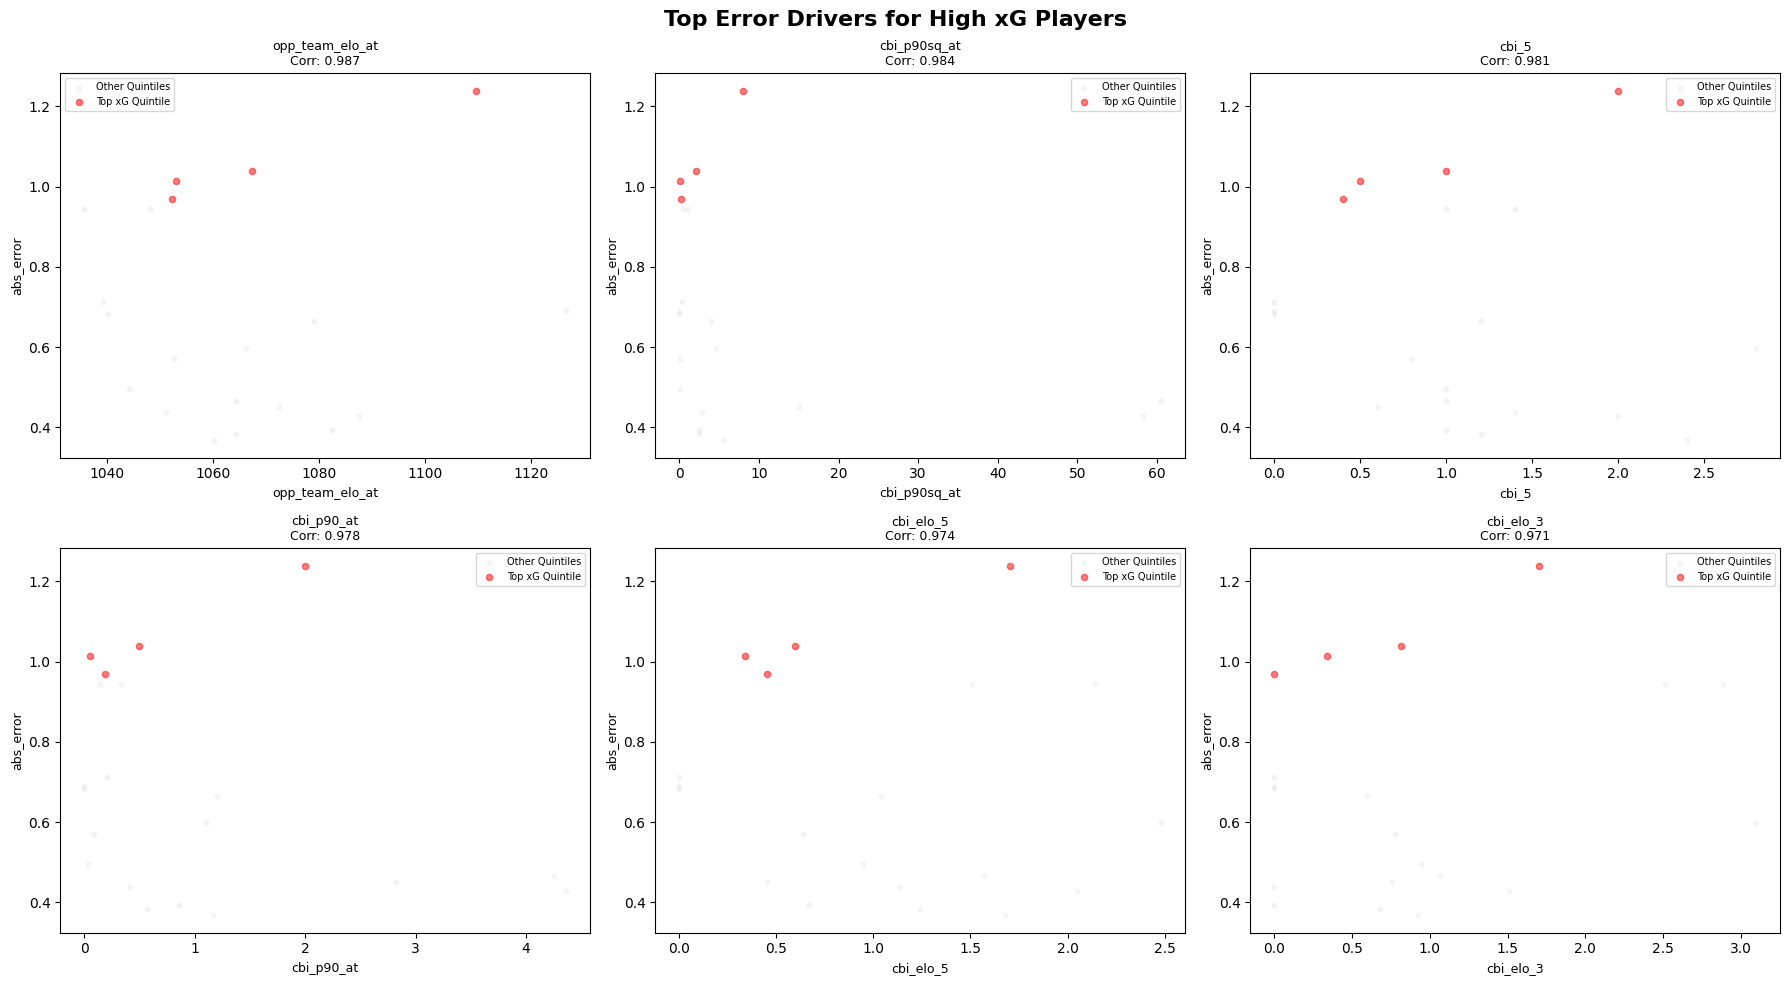


4. PREDICTION BIAS ANALYSIS

High xG Players:
  Over-predicted: 0 (0.0%)
  Under-predicted: 4 (100.0%)
  Mean Bias: -1.065

5. HIGH ERROR SUBGROUPS WITHIN TOP xG QUINTILE

Error by Position:
              mean  count
position                 
MID       1.064926      4

Error by Team Strength:
                   mean  count
team_strength                 
Weak           1.025760      2
Medium         0.969090      1
Strong         1.239092      1

Error by Opponent Strength:
                  mean  count
opp_strength                 
Weak          1.003740      2
Medium        1.013130      1
Strong        1.239092      1

Error by Home/Away:
              mean  count
was_home                 
false     1.073771      3
true      1.038390      1

6. SUGGESTED IMPROVEMENTS FOR HIGH xG PLAYERS

Recommendations:

1. ✓ Add INTERACTION term: 'opp_team_elo_at' × 'cbi_p90sq_at' (|Corr|: 0.985)


C:\Users\Chris\AppData\Local\Temp\ipykernel_16108\1128755521.py:147: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  team_errors = top_quintile.groupby('team_strength')[error_col].agg(['mean', 'count'])
C:\Users\Chris\AppData\Local\Temp\ipykernel_16108\1128755521.py:159: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  opp_errors = top_quintile.groupby('opp_strength')[error_col].agg(['mean', 'count'])


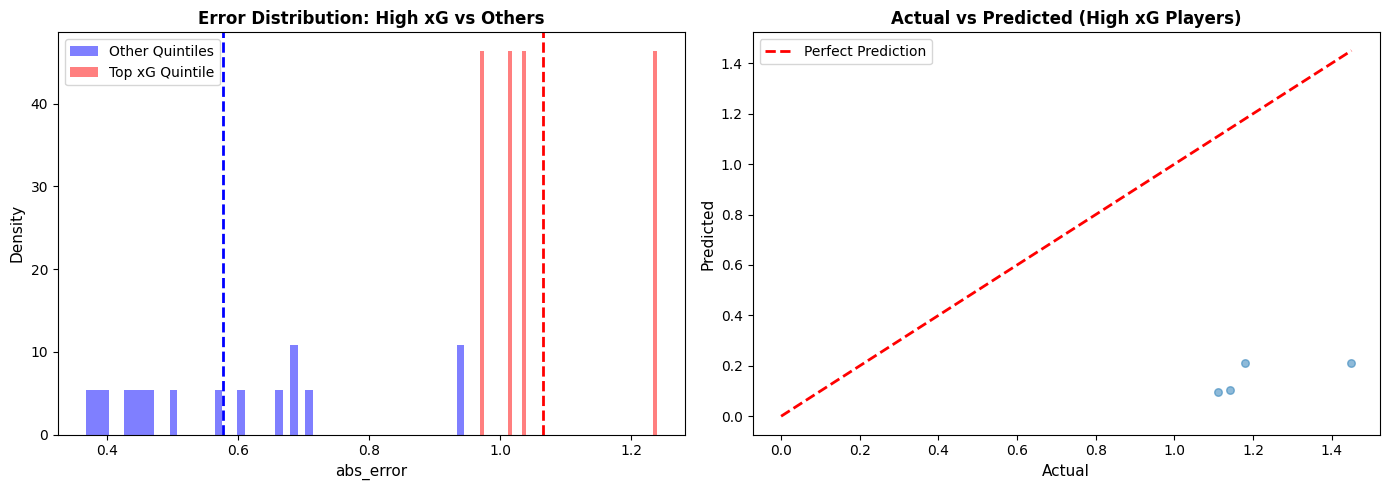

In [ ]:
# USAGE:
results = analyze_high_xg_errors(MID_xG_errors, xg_col='expected_goals', error_col='abs_error')

Cleaned df size: 866/13902

Training Set Performance:
R² Score: 0.9291
RMSE: 9.6088
MAE: 7.2057

Test Set Performance:
R² Score: 0.5606
RMSE: 24.2938
MAE: 16.8367

Top 20 Feature Importances:
                                      feature  importance
                                    minutes_3    0.452745
                                minutes_elo_3    0.033791
        xgoal_involvements_x_defensive_cont_3    0.019238
                        xgoals_conceded_elo_5    0.015212
                                    minutes_5    0.010205
       xgoal_involvements_x_defensive_cont_at    0.007402
                          xassists_elo_p90_10    0.006176
                                 opp_team_elo    0.006131
                            xassists_p90sq_at    0.006084
                           total_points_elo_3    0.005836
                     xgoal_involvements_p90_3    0.005704
                            xgoals_conceded_3    0.005621
                        clean_sheets_p90sq_at    0.005

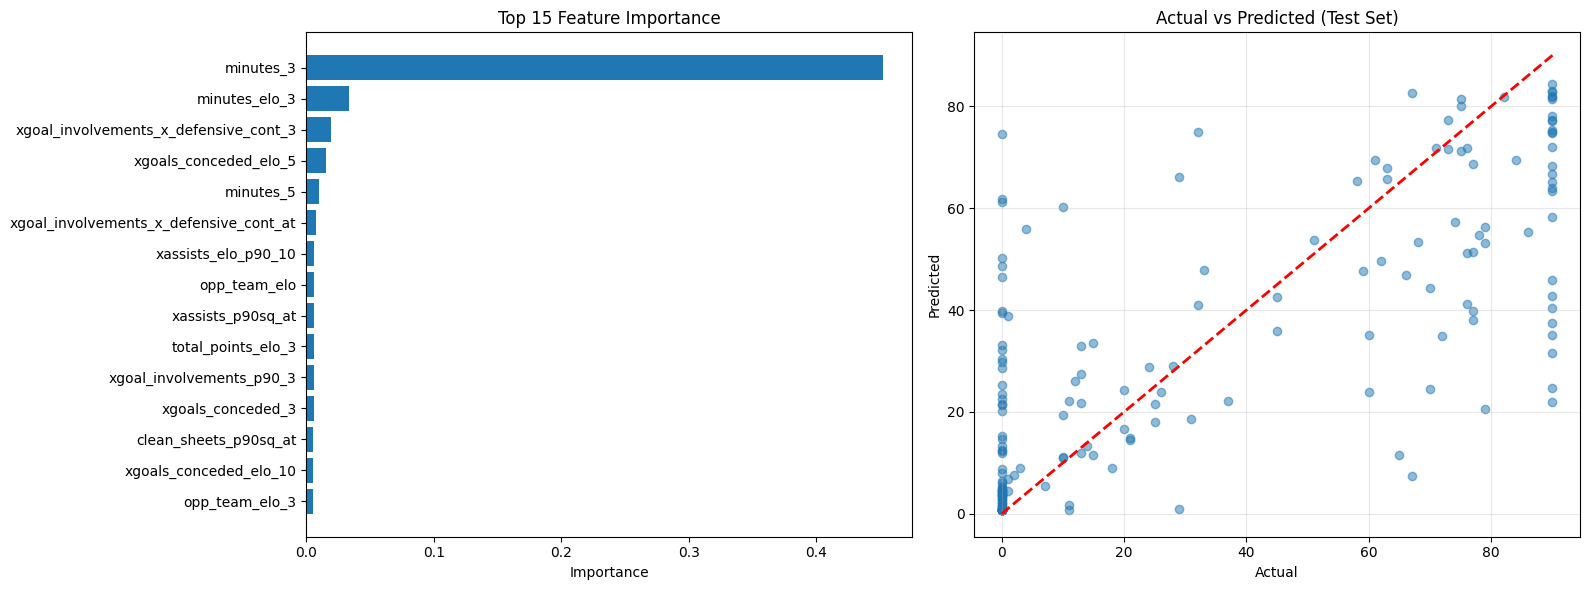

Cleaned df size: 3418/50201

Training Set Performance:
R² Score: 0.8357
RMSE: 15.3683
MAE: 11.9368

Test Set Performance:
R² Score: 0.5056
RMSE: 26.7004
MAE: 20.1338

Top 20 Feature Importances:
                                  feature  importance
                                minutes_3    0.460112
                            minutes_elo_3    0.030667
                                   bps_10    0.022369
    xgoal_involvements_x_defensive_cont_3    0.009384
                                minutes_5    0.008855
                     xgoal_involvements_3    0.007577
                             opp_team_elo    0.006018
xgoal_involvements_x_defensive_cont_p90_3    0.005749
                               minutes_10    0.005181
                                 elo_diff    0.004956
                 xgoal_involvements_elo_3    0.004943
                                    bps_3    0.004863
                           opp_team_elo_3    0.004713
                         minutes_p90sq_at    0.00

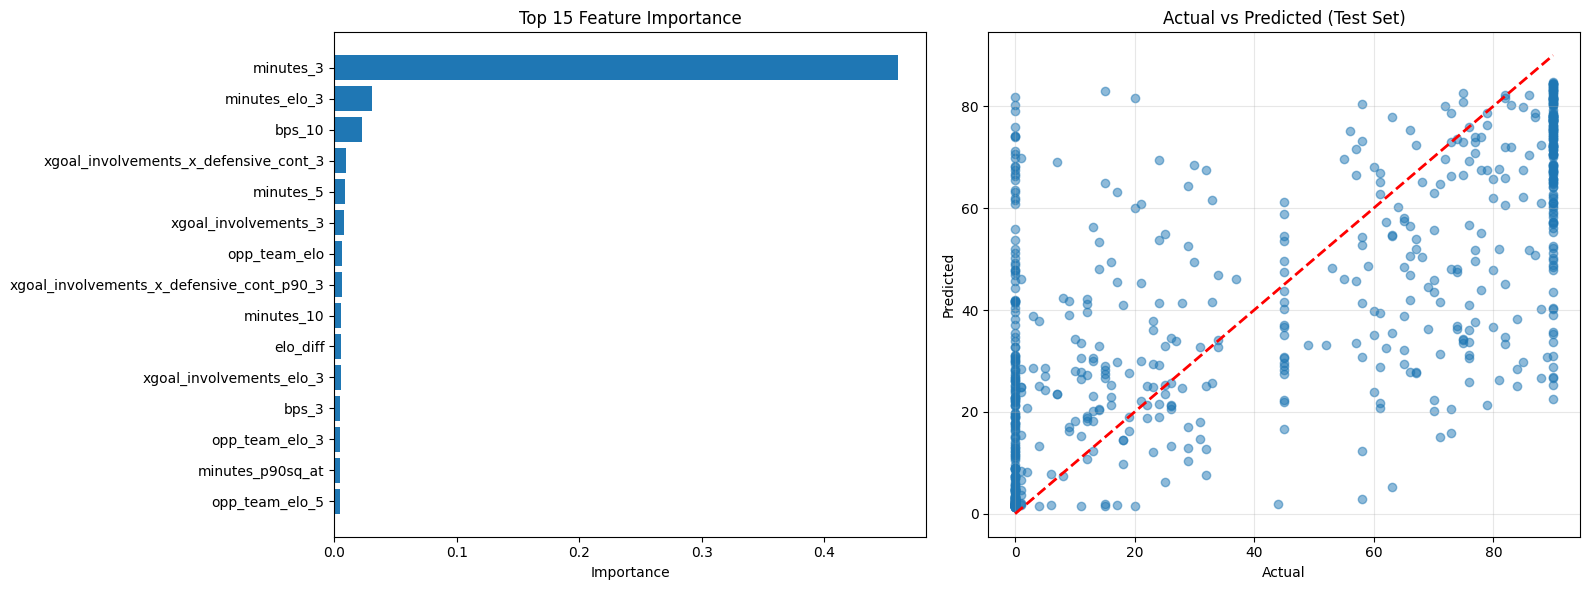

Cleaned df size: 2604/39301

Training Set Performance:
R² Score: 0.8477
RMSE: 16.3873
MAE: 12.0160

Test Set Performance:
R² Score: 0.4620
RMSE: 30.7728
MAE: 22.7737

Top 20 Feature Importances:
                              feature  importance
                            minutes_3    0.483171
                        minutes_elo_3    0.027633
                 opp_team_elo_p90sq_3    0.009427
                            minutes_5    0.008140
                         opp_team_elo    0.008089
                   recoveries_p90sq_3    0.007293
                         cbi_p90sq_10    0.006073
                       opp_team_elo_5    0.005864
                    team_elo_p90sq_at    0.005772
                      opp_team_elo_10    0.005606
                       opp_team_elo_3    0.005481
                          bps_p90sq_3    0.005314
                         bps_p90sq_at    0.005251
                           minutes_10    0.005008
                             elo_diff    0.004766
     

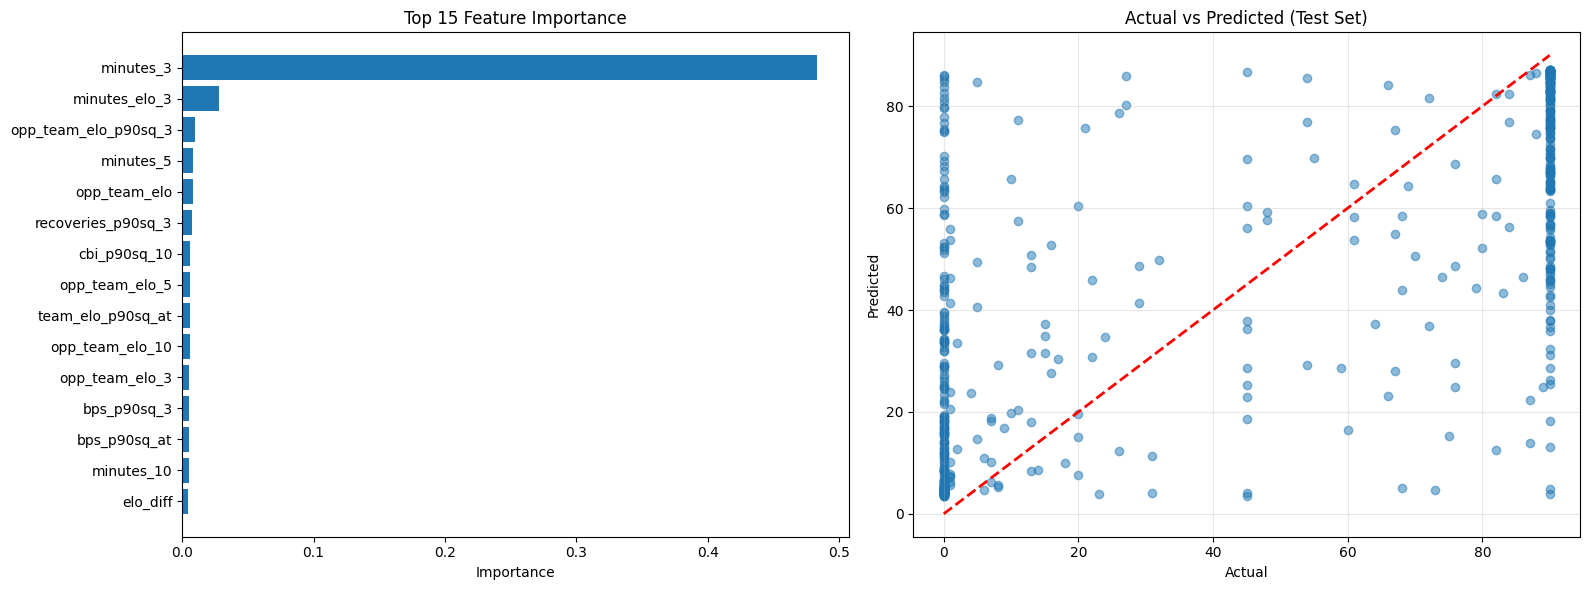

Cleaned df size: 471/8325

Training Set Performance:
R² Score: 0.9291
RMSE: 11.3105
MAE: 6.4431

Test Set Performance:
R² Score: 0.6327
RMSE: 24.6009
MAE: 14.4615

Top 20 Feature Importances:
                 feature  importance
      recoveries_p90sq_3    0.167135
       saves_elo_p90sq_3    0.063924
  opp_team_elo_elo_p90_3    0.062927
        team_elo_p90sq_3    0.060782
       minutes_elo_p90_3    0.042946
               minutes_3    0.038674
  total_points_elo_p90_3    0.034262
      total_points_elo_3    0.027449
total_points_elo_p90sq_3    0.025115
           minutes_elo_3    0.024401
      team_elo_elo_p90_3    0.024301
           bps_elo_p90_3    0.022733
         minutes_p90sq_3    0.018711
             team_elo_10    0.014029
              team_elo_5    0.014021
          opp_team_elo_3    0.013664
  recoveries_elo_p90sq_3    0.013560
               bps_elo_3    0.013006
         opp_team_elo_10    0.010659
    opp_team_elo_p90sq_3    0.009691


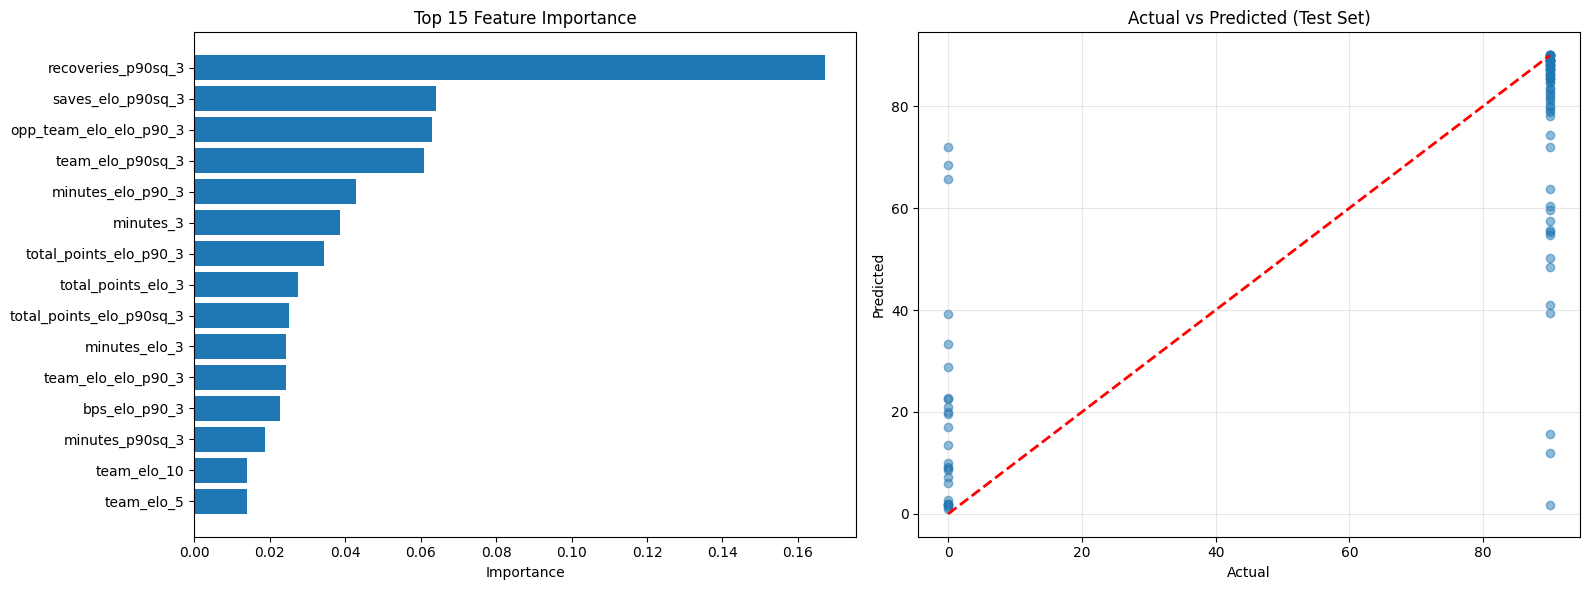

In [ ]:
filtered = (df['player_season_minutes_total']>0)#&(df['total_points']<15)#&(df['minutes']>45)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[filtered],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid
        )
    FWD_mins_predictor.fit()
    FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[filtered],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid)
    MID_mins_predictor.fit()
    MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[filtered],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid)
    DEF_mins_predictor.fit()
    DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[filtered],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols)
    GK_mins_predictor.fit()
    GK_mins_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 270/4215

Training Set Performance:
R² Score: 0.8472
RMSE: 0.1874
MAE: 0.1462

Test Set Performance:
R² Score: -0.0520
RMSE: 0.4064
MAE: 0.3126

Top 20 Feature Importances:
                 feature  importance
    xgoal_involvements_5    0.062765
   xgoals_conceded_elo_5    0.028592
          bonus_p90sq_at    0.026155
                xgoals_5    0.024059
 goals_conceded_p90sq_at    0.020101
         xgoals_p90sq_at    0.017477
     xassists_elo_p90_10    0.014548
      recoveries_p90sq_5    0.012370
     tackles_elo_p90sq_3    0.011646
          opp_team_elo_5    0.011374
xgoals_conceded_p90sq_at    0.010983
       xgoals_conceded_3    0.010192
   total_points_p90sq_at    0.010135
   goals_conceded_elo_10    0.010038
  defensive_cont_p90sq_5    0.009752
            opp_team_elo    0.009213
     recoveries_p90sq_at    0.008858
                elo_diff    0.008527
         opp_team_elo_10    0.008212
         tackles_p90sq_3

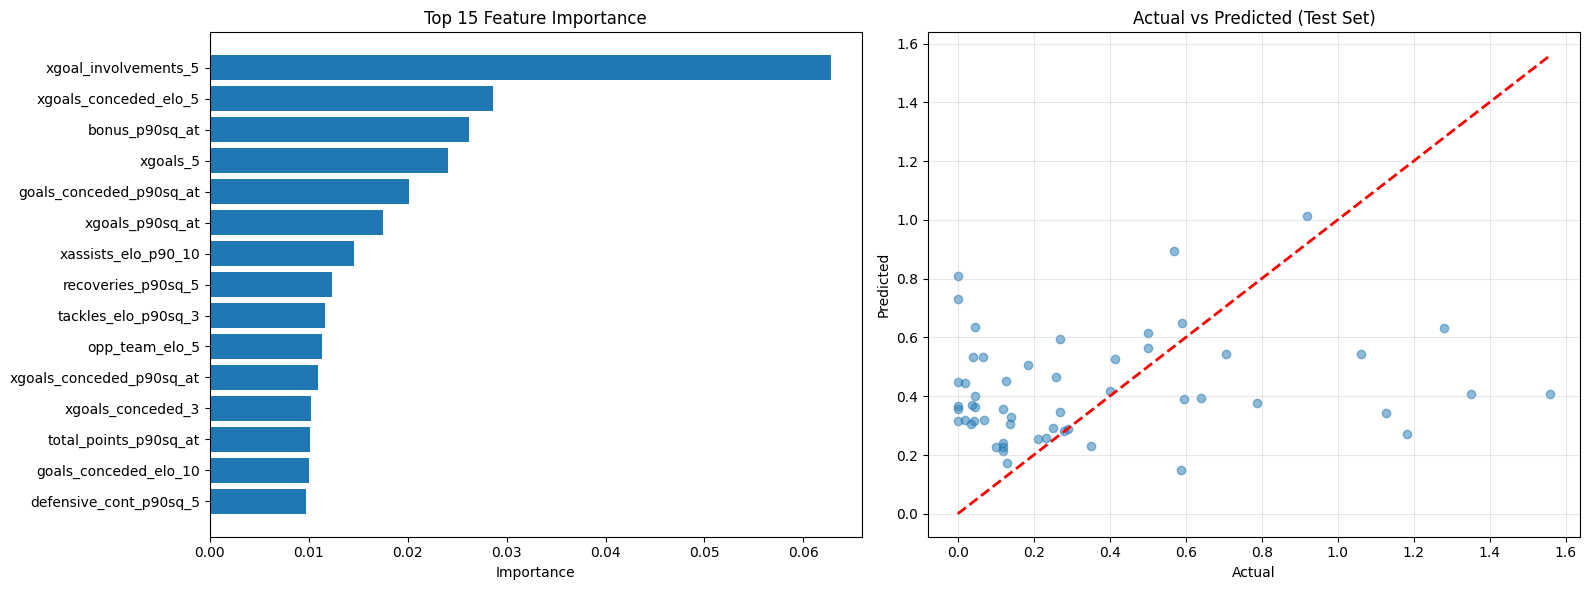

target=expected_goals_per90, MID_xG_predictor
Cleaned df size: 1340/17527

Training Set Performance:
R² Score: 0.7634
RMSE: 0.1124
MAE: 0.0848

Test Set Performance:
R² Score: 0.0436
RMSE: 0.2343
MAE: 0.1526

Top 20 Feature Importances:
                                   feature  importance
                   goals_conceded_p90sq_10    0.023844
                              opp_team_elo    0.023765
                xgoal_involvements_p90sq_5    0.022484
               xgoal_involvements_p90sq_at    0.016395
                             xgoals_elo_10    0.015591
                  xgoal_involvements_elo_5    0.014497
                    defensive_cont_p90sq_3    0.012692
                     xgoal_involvements_10    0.012241
                                 xgoals_10    0.012223
                 xgoal_involvements_elo_10    0.011959
                     goals_conceded_p90_10    0.011924
              xgoal_involvements_elo_p90_5    0.011494
                              xgoals_elo_5    0.

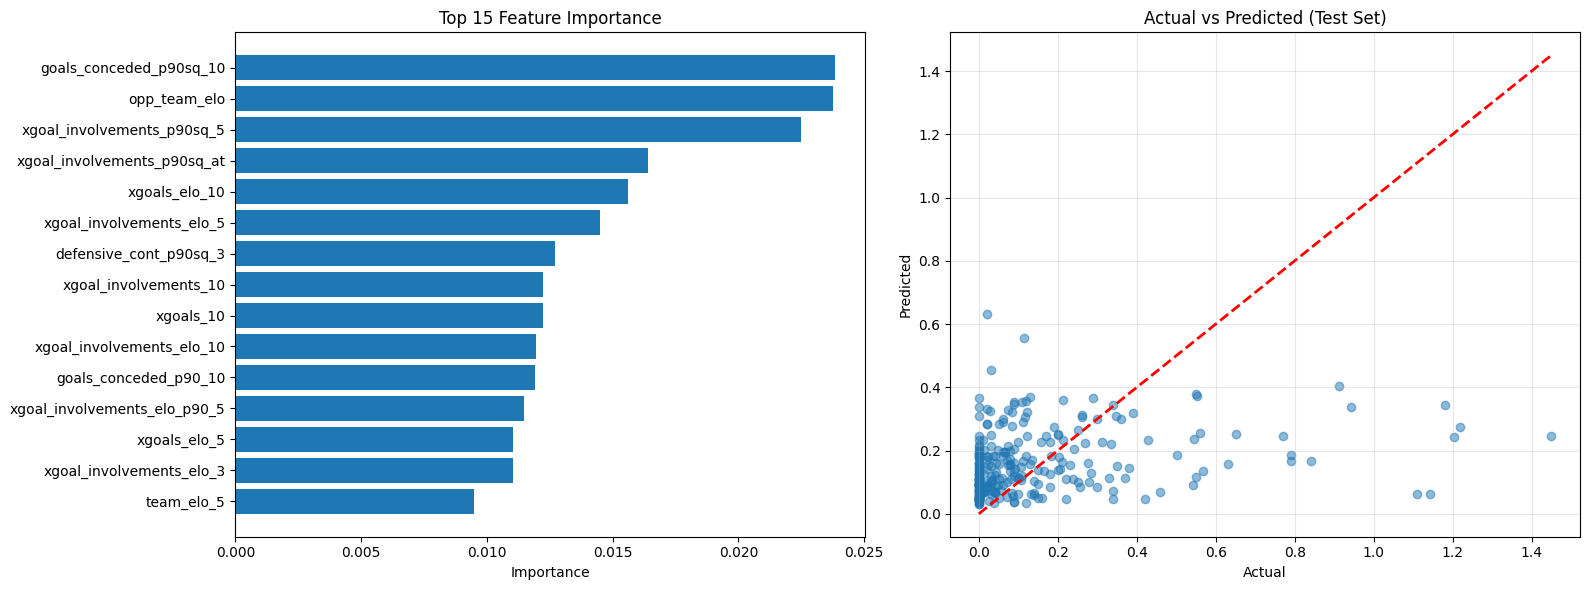

target=expected_goals_per90, DEF_xG_predictor
Cleaned df size: 1176/15439

Training Set Performance:
R² Score: 0.7211
RMSE: 0.0694
MAE: 0.0465

Test Set Performance:
R² Score: -0.0749
RMSE: 0.0963
MAE: 0.0642

Top 20 Feature Importances:
                      feature  importance
                 opp_team_elo    0.030633
                     elo_diff    0.026275
          recoveries_p90sq_10    0.020863
                 bps_p90sq_at    0.020250
                    bps_elo_5    0.019901
                   bps_p90_10    0.018489
              opp_team_elo_10    0.017614
        goals_scored_p90sq_at    0.016471
               bps_elo_p90_10    0.015980
                   bps_elo_10    0.015824
        opp_team_elo_p90sq_at    0.015520
               opp_team_elo_5    0.012853
                bps_elo_p90_5    0.012065
          tackles_elo_p90sq_3    0.011378
         goals_conceded_elo_5    0.011085
             minutes_p90sq_at    0.010287
  xgoal_involvements_p90sq_at    0.010173
      

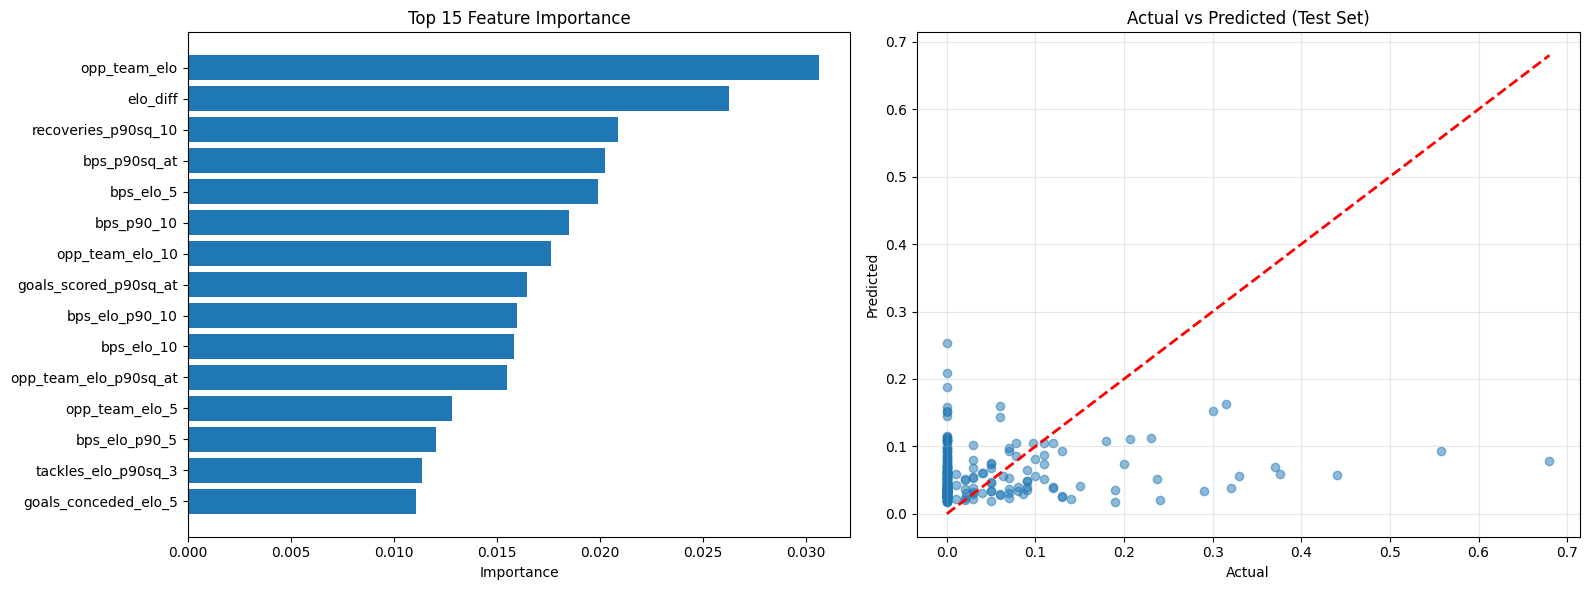

In [ ]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>500)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid)
    FWD_xG_predictor.fit()
    FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid)
    MID_xG_predictor.fit()
    MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid)
    DEF_xG_predictor.fit()
    DEF_xG_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 270/4215

Training Set Performance:
R² Score: 0.7923
RMSE: 0.0357
MAE: 0.0224

Test Set Performance:
R² Score: -1.5891
RMSE: 0.0884
MAE: 0.0619

Top 20 Feature Importances:
                 feature  importance
       goals_conceded_10    0.104805
                elo_diff    0.039582
   xgoals_conceded_elo_3    0.035460
         xgoals_p90sq_10    0.034256
     recoveries_p90sq_at    0.026262
               bps_elo_3    0.022154
  recoveries_elo_p90sq_3    0.019365
              minutes_10    0.018681
          opp_team_elo_3    0.018358
   goals_conceded_elo_10    0.018238
   opp_team_elo_p90sq_10    0.018196
          bonus_p90sq_at    0.016540
     xgoals_elo_p90sq_10    0.011261
       xassists_p90sq_at    0.010384
           minutes_elo_3    0.010341
       team_elo_p90sq_10    0.009826
clean_sheets_elo_p90sq_3    0.009729
 opp_team_elo_elo_p90_10    0.009143
      recoveries_p90sq_5    0.008421
               minutes

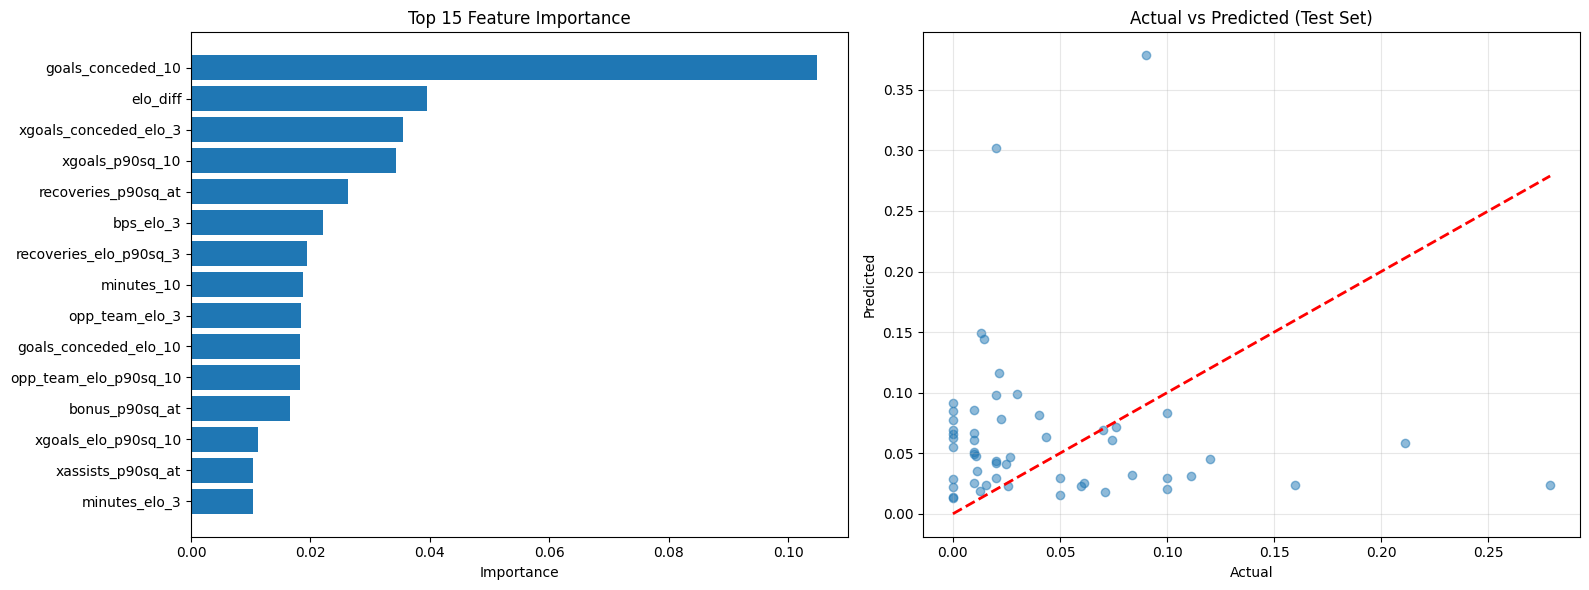

target=expected_assists_per90, MID_xA_predictor
Cleaned df size: 1340/17527

Training Set Performance:
R² Score: 0.7462
RMSE: 0.0798
MAE: 0.0596

Test Set Performance:
R² Score: -0.0261
RMSE: 0.1458
MAE: 0.1002

Top 20 Feature Importances:
                                       feature  importance
                           xassists_elo_p90_10    0.044327
                                    xassists_5    0.024454
                                      elo_diff    0.024302
                                  opp_team_elo    0.022103
                            minutes_elo_p90_10    0.015068
    xgoal_involvements_x_defensive_cont_p90_at    0.014804
                    defensive_cont_elo_p90sq_5    0.014035
                               xassists_p90_10    0.013655
                                   xassists_10    0.013212
                              xassists_p90sq_3    0.010103
    xgoal_involvements_x_defensive_cont_p90_10    0.010064
                               xassists_elo_10    0.

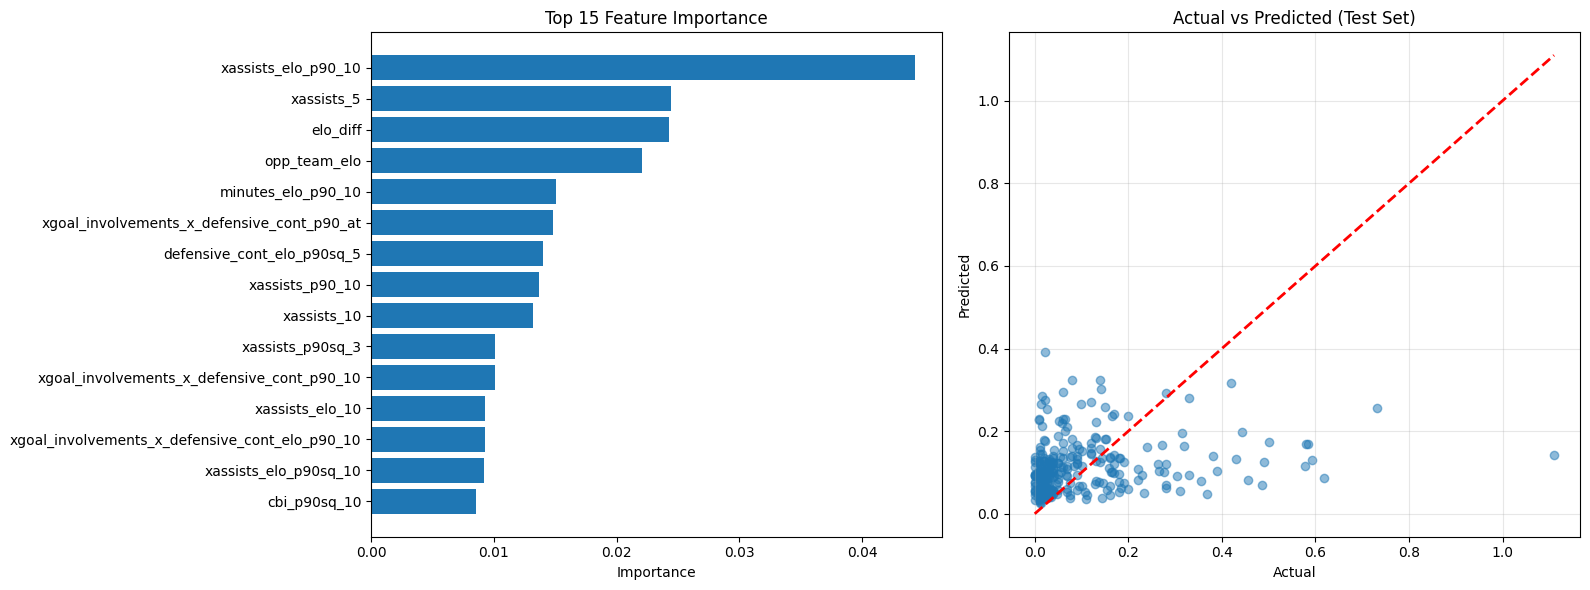

target=expected_assists_per90, DEF_xA_predictor
Cleaned df size: 1176/15439

Training Set Performance:
R² Score: 0.7615
RMSE: 0.0503
MAE: 0.0345

Test Set Performance:
R² Score: -0.0005
RMSE: 0.1119
MAE: 0.0684

Top 20 Feature Importances:
                    feature  importance
          xassists_p90sq_at    0.052514
        recoveries_p90sq_at    0.028598
               opp_team_elo    0.026491
            xassists_p90_10    0.016709
                   elo_diff    0.014197
            total_points_10    0.013550
            tackles_p90sq_3    0.013431
                xassists_10    0.013223
          xgoals_conceded_3    0.012971
      total_points_p90sq_at    0.012540
                  bps_elo_3    0.011939
             opp_team_elo_5    0.011684
             total_points_5    0.011666
            tackles_p90sq_5    0.011474
xgoal_involvements_p90sq_at    0.010358
             opp_team_elo_3    0.009977
      opp_team_elo_p90sq_at    0.009509
                      bps_5    0.009101


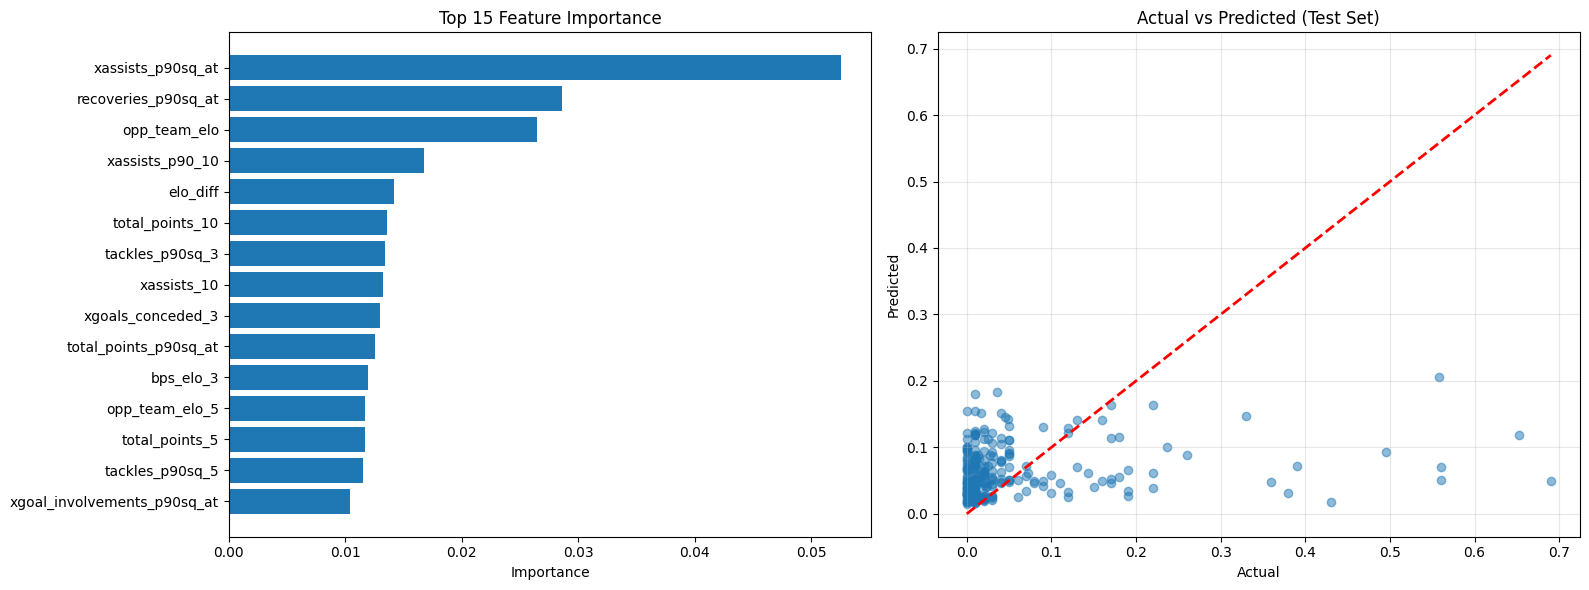

In [ ]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>500)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols)
    FWD_xA_predictor.fit()
    FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols)
    MID_xA_predictor.fit()
    MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols)
    DEF_xA_predictor.fit()
    DEF_xA_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 270/4215

Training Set Performance:
R² Score: 0.8415
RMSE: 0.3237
MAE: 0.2589

Test Set Performance:
R² Score: -0.1415
RMSE: 0.8462
MAE: 0.7136

Top 20 Feature Importances:
                                   feature  importance
                                  elo_diff    0.101161
                      opp_team_elo_p90sq_3    0.027302
                       recoveries_p90sq_at    0.024545
                              opp_team_elo    0.022486
                            opp_team_elo_3    0.016247
                        recoveries_p90sq_5    0.014727
                       recoveries_p90sq_10    0.014647
                         xgoals_conceded_3    0.012899
                      goals_conceded_elo_3    0.010523
                            opp_team_elo_5    0.009991
                     xgoals_conceded_elo_3    0.009376
                          team_elo_p90sq_5    0.009228
                         xassists_p90sq

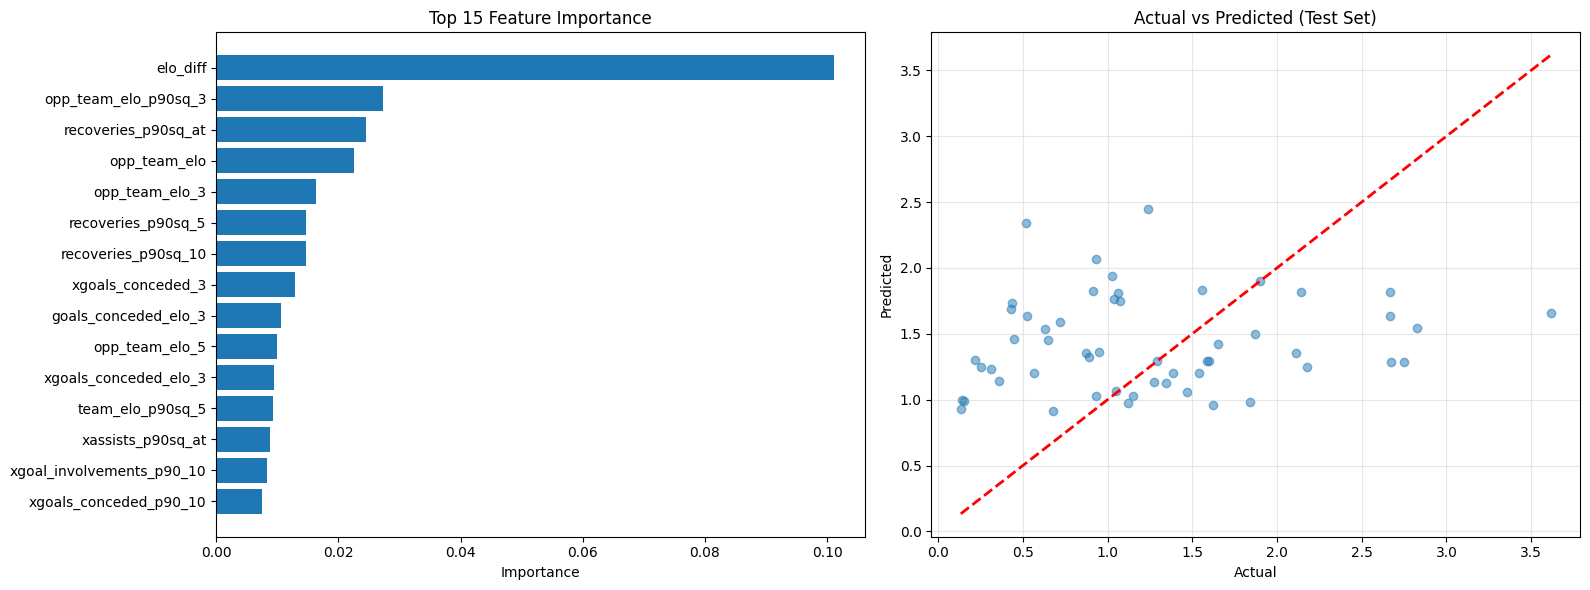

target=expected_goals_conceded_per90, MID_xGC_predictor
Cleaned df size: 1340/17527

Training Set Performance:
R² Score: 0.8336
RMSE: 0.3183
MAE: 0.2585

Test Set Performance:
R² Score: 0.4202
RMSE: 0.5902
MAE: 0.4588

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.156184
             opp_team_elo_3    0.050946
               opp_team_elo    0.048556
                   team_elo    0.044935
             opp_team_elo_5    0.035541
            opp_team_elo_10    0.023980
                 team_elo_3    0.020683
                 team_elo_5    0.014509
            team_elo_elo_10    0.011903
             team_elo_elo_3    0.010487
                team_elo_10    0.009164
        opp_team_elo_elo_10    0.008300
    xgoals_conceded_p90sq_5    0.008214
         opp_team_elo_elo_3    0.008105
             team_elo_elo_5    0.007828
         opp_team_elo_elo_5    0.007371
          minutes_elo_p90_5    0.006327
        minutes_elo_p90sq_3    0.

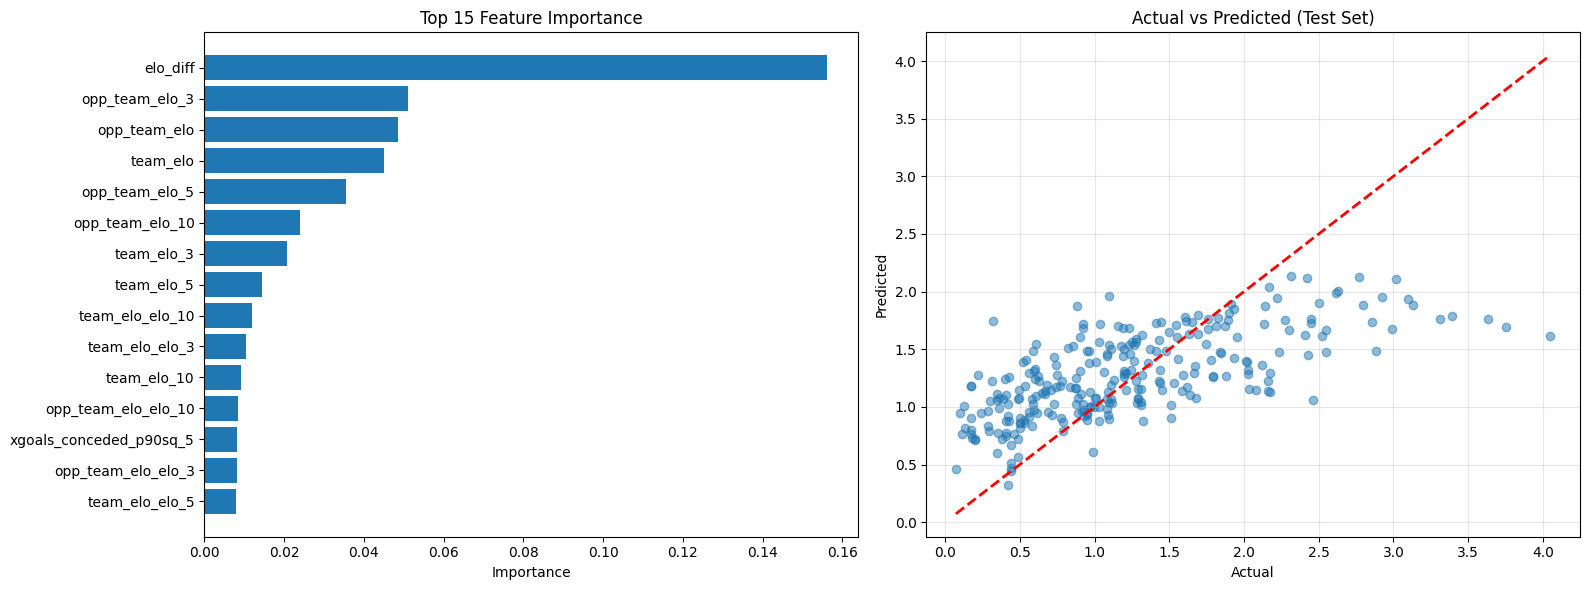

target=expected_goals_conceded_per90, DEF_xGC_predictor
Cleaned df size: 1176/15439

Training Set Performance:
R² Score: 0.8525
RMSE: 0.3149
MAE: 0.2512

Test Set Performance:
R² Score: 0.3835
RMSE: 0.6244
MAE: 0.4728

Top 20 Feature Importances:
                     feature  importance
                    elo_diff    0.157426
              opp_team_elo_3    0.045455
                opp_team_elo    0.042214
              opp_team_elo_5    0.032424
                 team_elo_10    0.030926
                    team_elo    0.029463
                  team_elo_5    0.020805
                  team_elo_3    0.016878
             opp_team_elo_10    0.016238
         minutes_elo_p90sq_5    0.014252
              team_elo_elo_5    0.013768
          opp_team_elo_elo_3    0.011918
     xgoals_conceded_p90sq_5    0.011504
          opp_team_elo_elo_5    0.010727
        opp_team_elo_p90sq_3    0.009950
          xgoals_conceded_10    0.008605
            tackles_p90sq_at    0.007680
   clean_sheets

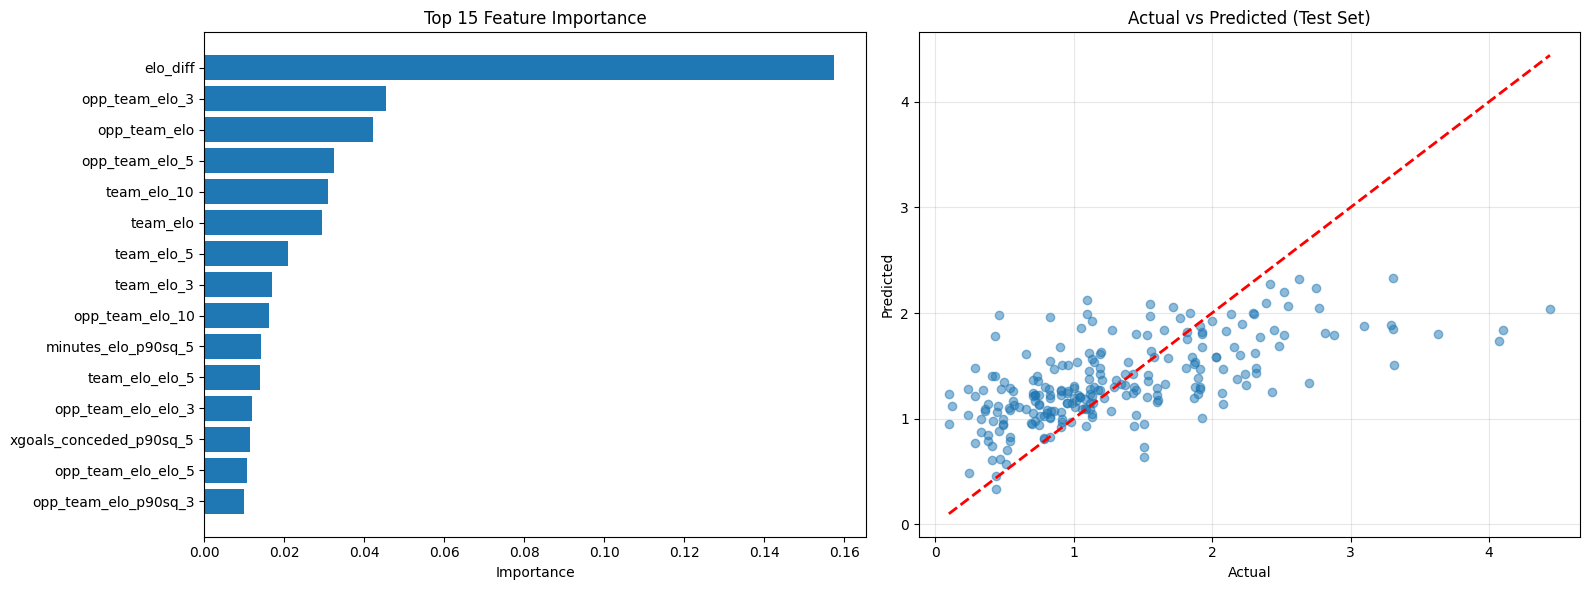

target=expected_goals_conceded_per90, GK_xGC_predictor
Cleaned df size: 288/3755

Training Set Performance:
R² Score: 0.8595
RMSE: 0.3061
MAE: 0.2463

Test Set Performance:
R² Score: -0.1189
RMSE: 0.8405
MAE: 0.6531

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.147875
            opp_team_elo_10    0.024935
               opp_team_elo    0.019695
      xgoals_conceded_p90_3    0.017228
    xgoals_conceded_p90sq_3    0.016373
       opp_team_elo_p90sq_5    0.015370
           team_elo_p90sq_3    0.014693
      opp_team_elo_p90sq_10    0.014575
                   team_elo    0.014153
                team_elo_10    0.013945
           team_elo_p90sq_5    0.013885
    xgoals_conceded_p90sq_5    0.013206
   xgoals_conceded_p90sq_10    0.013184
             opp_team_elo_3    0.012407
          saves_elo_p90sq_5    0.012179
xgoals_conceded_elo_p90sq_5    0.011531
                 team_elo_5    0.011513
      xgoals_conceded_elo_3    0.01

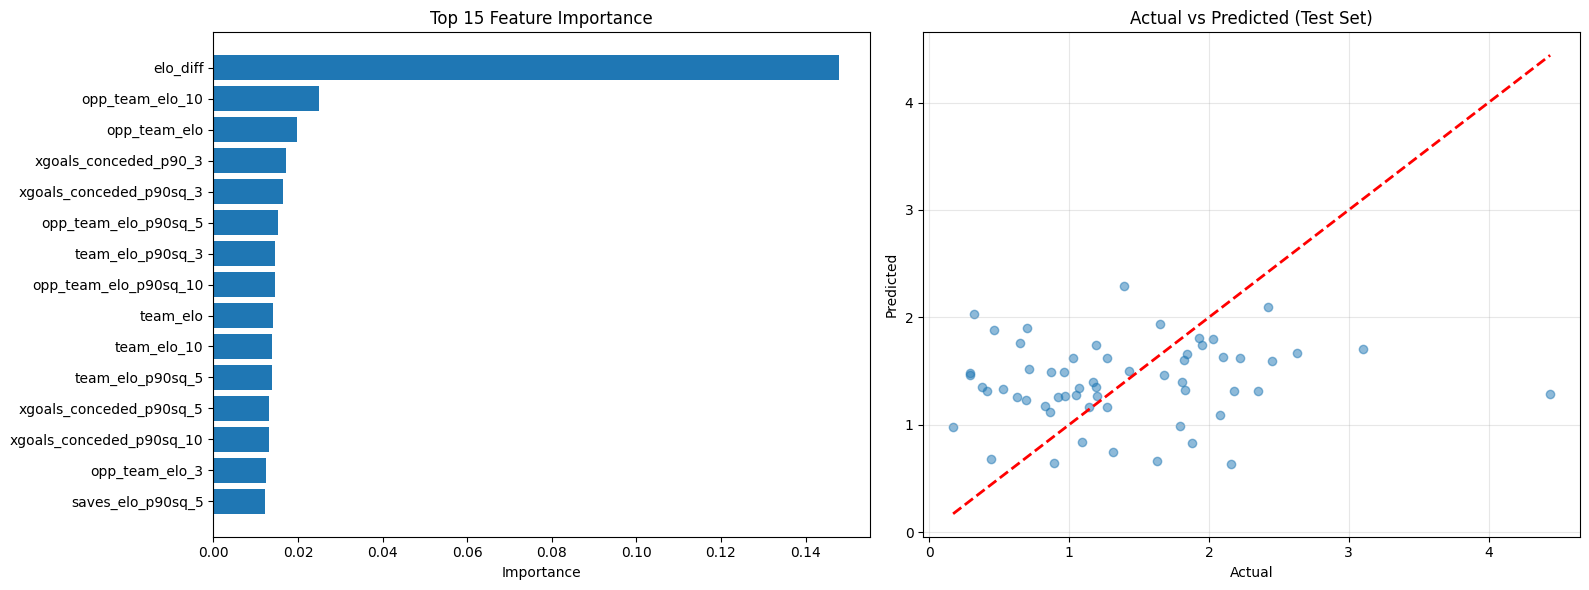

In [ ]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>500)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols)
    FWD_xGC_predictor.fit()
    FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols)
    MID_xGC_predictor.fit()
    MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols)
    DEF_xGC_predictor.fit()
    DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols)
    GK_xGC_predictor.fit()
    GK_xGC_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 270/4215

Training Set Performance:
R² Score: 0.8151
RMSE: 8.1845
MAE: 6.5721

Test Set Performance:
R² Score: -0.2967
RMSE: 19.4257
MAE: 15.6688

Top 20 Feature Importances:
                    feature  importance
          minutes_elo_p90_5    0.049031
        minutes_elo_p90sq_5    0.036897
      xgoals_conceded_elo_5    0.032093
      clean_sheets_p90sq_10    0.023409
             opp_team_elo_3    0.021707
      goals_conceded_elo_10    0.017759
        minutes_elo_p90sq_3    0.014882
       minutes_elo_p90sq_10    0.014195
         clean_sheets_elo_3    0.013777
        xassists_elo_p90_10    0.013195
    goals_conceded_p90sq_10    0.011911
      xassists_elo_p90sq_10    0.011673
       xgoal_involvements_5    0.011379
          xgoals_conceded_5    0.010693
            xgoals_p90sq_at    0.010647
xgoal_involvements_p90sq_at    0.010035
     defensive_cont_p90sq_5    0.009307
            xassists_p90_10    0.009253
            

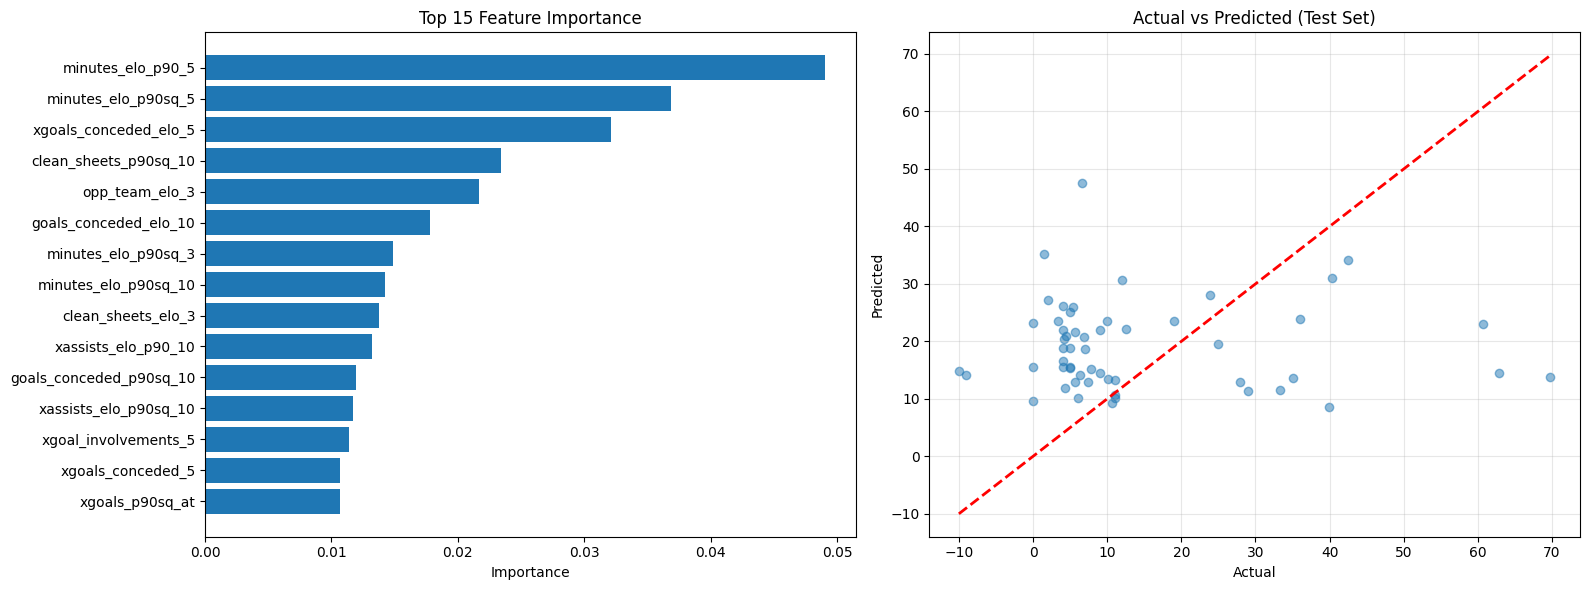

target=bps_per90, MID_bps_predictor
Cleaned df size: 1340/17527

Training Set Performance:
R² Score: 0.6291
RMSE: 7.3135
MAE: 5.7578

Test Set Performance:
R² Score: -0.0562
RMSE: 11.2335
MAE: 8.7582

Top 20 Feature Importances:
                                   feature  importance
                                  elo_diff    0.028322
                  clean_sheets_elo_p90sq_5    0.021778
     xgoal_involvements_x_defensive_cont_3    0.013954
                              opp_team_elo    0.013198
    xgoal_involvements_x_defensive_cont_at    0.012727
xgoal_involvements_x_defensive_cont_p90_10    0.012404
                    defensive_cont_p90sq_5    0.010431
                     opp_team_elo_p90sq_10    0.009869
                            opp_team_elo_5    0.009815
xgoal_involvements_x_defensive_cont_p90_at    0.009713
                   goals_conceded_p90sq_10    0.009117
                           opp_team_elo_10    0.008705
                          xassists_p90sq_3    0.008562
 

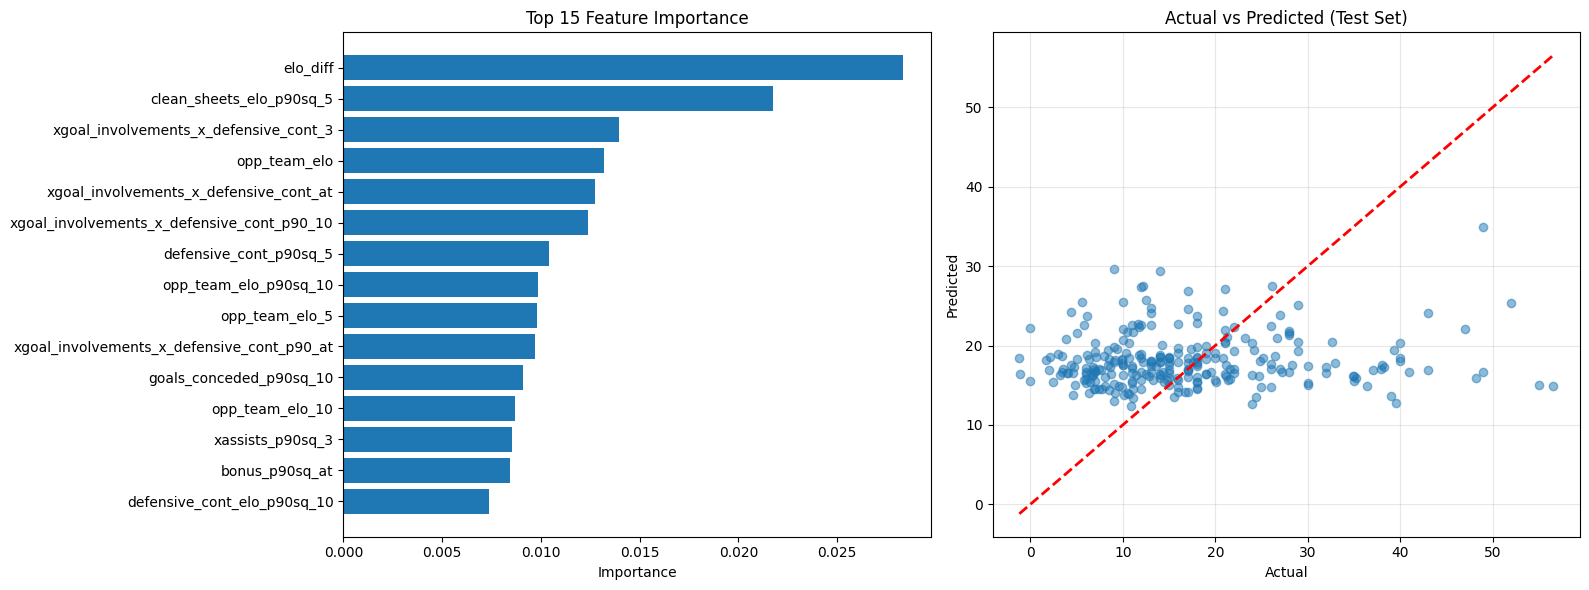

target=bps_per90, DEF_bps_predictor
Cleaned df size: 1176/15439

Training Set Performance:
R² Score: 0.7828
RMSE: 5.8405
MAE: 4.6981

Test Set Performance:
R² Score: 0.1742
RMSE: 11.5168
MAE: 9.0794

Top 20 Feature Importances:
                              feature  importance
                             elo_diff    0.155028
                       opp_team_elo_5    0.022326
                       opp_team_elo_3    0.017693
                      opp_team_elo_10    0.015614
                         opp_team_elo    0.015079
                       bps_elo_p90_10    0.012110
                 goals_conceded_elo_3    0.011252
                           bps_elo_10    0.010369
                 goals_conceded_elo_5    0.009672
                       team_elo_elo_5    0.009426
            xgoals_conceded_elo_p90_5    0.008546
                           bps_p90_10    0.008412
                   opp_team_elo_elo_5    0.007813
             xgoals_conceded_p90sq_at    0.007482
                      

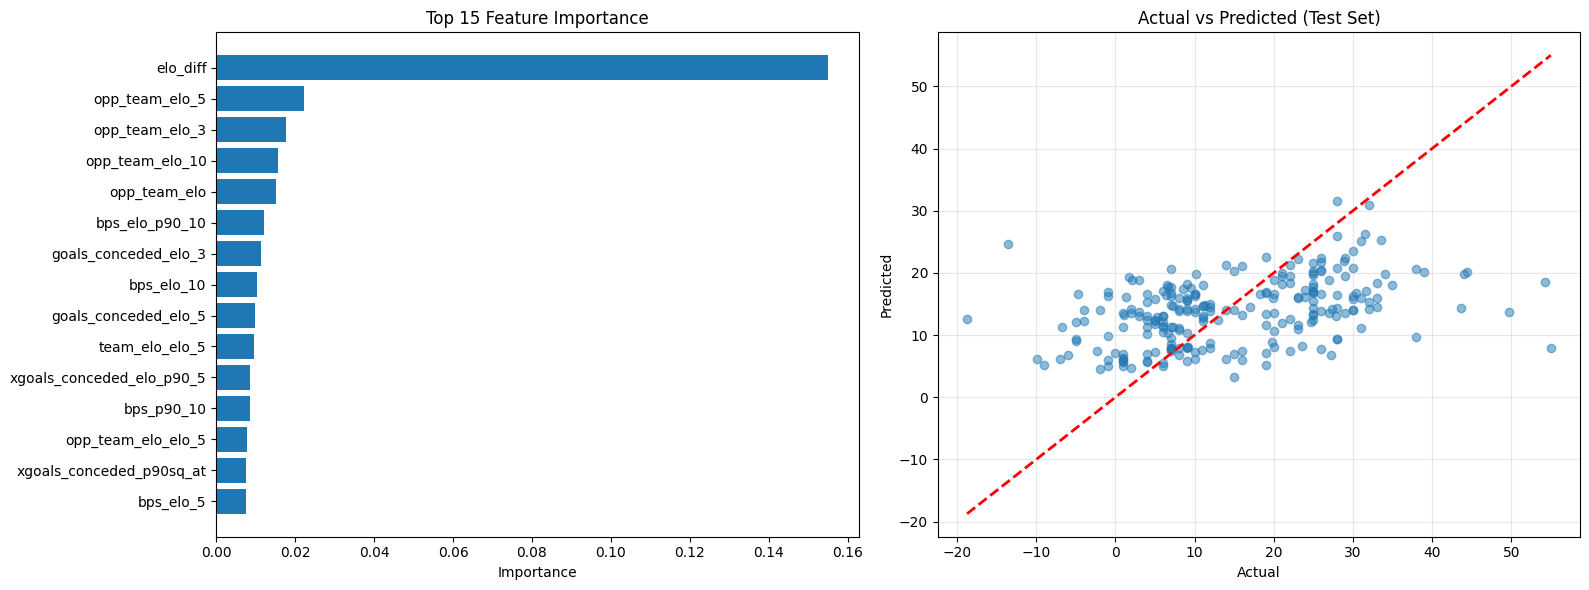

target=bps_per90, GK_bps_predictor
Cleaned df size: 288/3755

Training Set Performance:
R² Score: 0.8434
RMSE: 4.1107
MAE: 3.3151

Test Set Performance:
R² Score: -0.0536
RMSE: 9.8838
MAE: 7.7748

Top 20 Feature Importances:
                    feature  importance
       opp_team_elo_p90sq_3    0.022653
                   elo_diff    0.022011
             opp_team_elo_3    0.021613
               cbi_p90sq_at    0.020577
goals_conceded_elo_p90sq_10    0.019811
           bps_elo_p90sq_10    0.018894
               opp_team_elo    0.018271
             opp_team_elo_5    0.018213
            cbi_elo_p90sq_5    0.017691
         bonus_elo_p90sq_10    0.016832
 goals_conceded_elo_p90sq_5    0.016829
    recoveries_elo_p90sq_10    0.015229
         recoveries_p90sq_5    0.015054
         recoveries_p90sq_3    0.014931
      opp_team_elo_p90sq_10    0.012454
 goals_conceded_elo_p90sq_3    0.012251
        recoveries_p90sq_at    0.011650
      clean_sheets_p90sq_at    0.011369
     recoveries

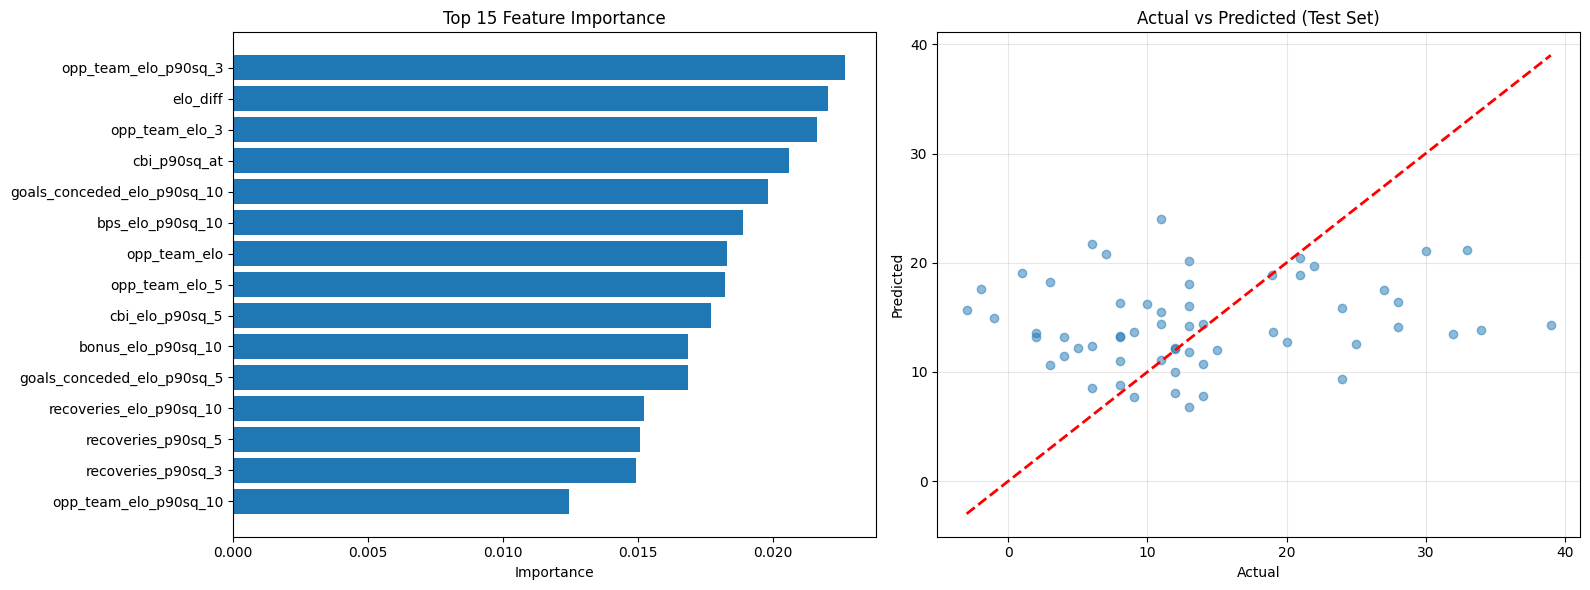

In [ ]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>500)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols)
    FWD_bps_predictor.fit()
    FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols)
    MID_bps_predictor.fit()
    MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols)
    DEF_bps_predictor.fit()
    DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols)
    GK_bps_predictor.fit()
    GK_bps_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 317/3919

Training Set Performance:
R² Score: 0.8377
RMSE: 0.6948
MAE: 0.5552

Test Set Performance:
R² Score: -0.0964
RMSE: 1.6532
MAE: 1.3171

Top 20 Feature Importances:
                   feature  importance
              opp_team_elo    0.034142
                  elo_diff    0.033087
            opp_team_elo_3    0.026631
          team_elo_p90sq_5    0.017491
               cbi_p90sq_5    0.016776
              cbi_p90sq_10    0.016501
     team_elo_elo_p90sq_10    0.015993
               team_elo_10    0.015267
           opp_team_elo_10    0.014323
              cbi_p90sq_at    0.013398
               saves_elo_5    0.013173
goals_conceded_elo_p90sq_5    0.012094
            opp_team_elo_5    0.010506
      opp_team_elo_p90sq_5    0.009967
           saves_elo_p90_5    0.009760
             cbi_elo_p90_5    0.009662
     clean_sheets_p90sq_at    0.009348
      opp_team_elo_p90sq_3    0.009255
                 cbi_p90_5    

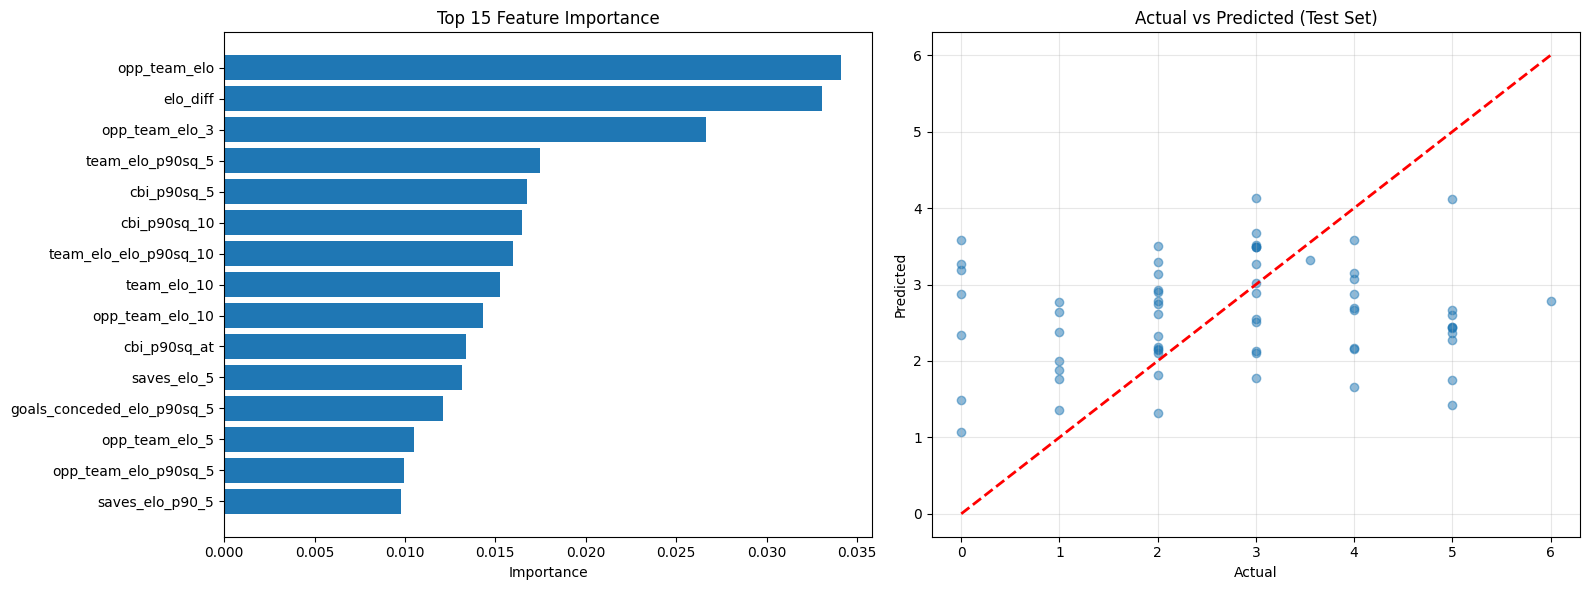

In [ ]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
    data=df[filtered],
    target='saves_per90',
    positions={'GK'})
    GK_saves_predictor.fit()
    GK_saves_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 348/4821

Training Set Performance:
R² Score: 0.8255
RMSE: 1.1690
MAE: 0.8952

Test Set Performance:
R² Score: -0.0779
RMSE: 2.9958
MAE: 2.1894

Top 20 Feature Importances:
                    feature  importance
             opp_team_elo_5    0.036815
             xassists_elo_3    0.029268
            xassists_elo_10    0.016773
       defensive_cont_elo_5    0.014790
            opp_team_elo_10    0.011695
               opp_team_elo    0.011580
       goals_conceded_p90_5    0.011079
      goals_scored_p90sq_at    0.011066
    goals_conceded_p90sq_at    0.010470
       minutes_elo_p90sq_10    0.010447
             opp_team_elo_3    0.010368
                 team_elo_3    0.009940
  clean_sheets_elo_p90sq_10    0.009382
        minutes_elo_p90sq_5    0.009028
             bonus_p90sq_at    0.008746
xgoal_involvements_p90sq_at    0.008484
      goals_conceded_p90_10    0.008418
          xassists_p90sq_at    0

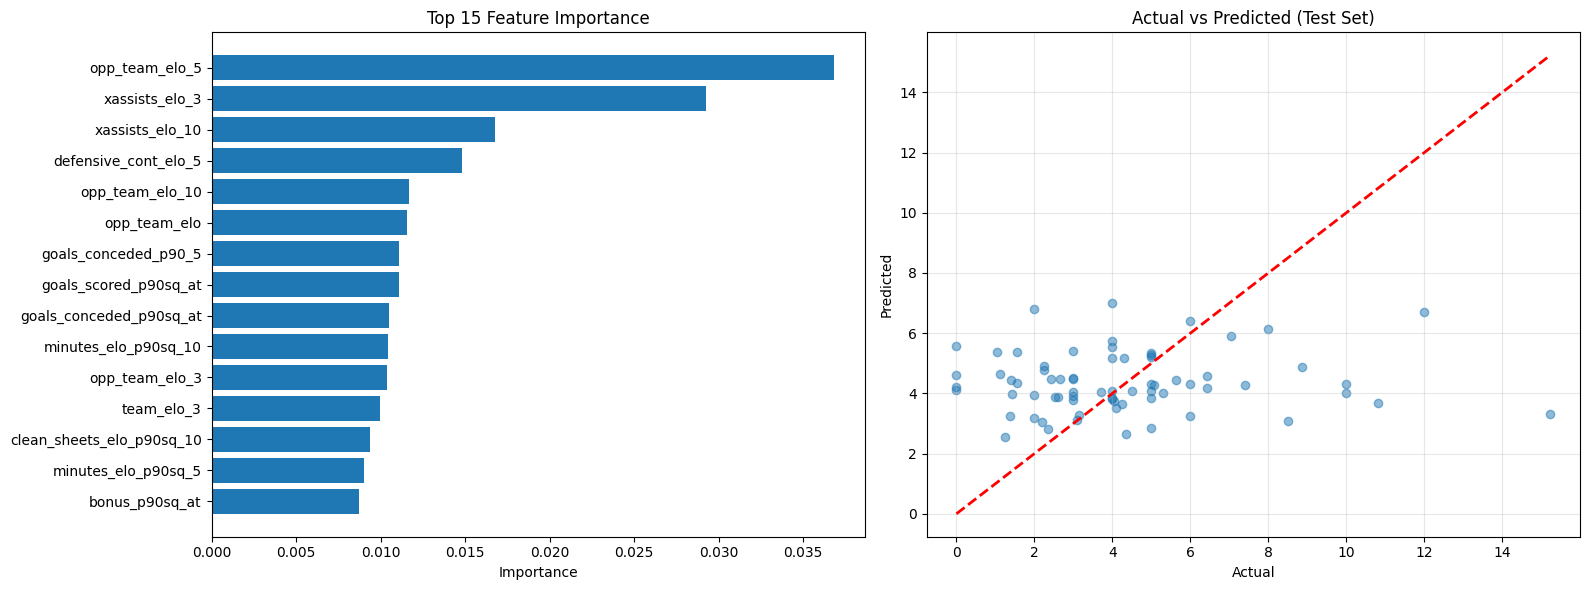

target=defensive_contribution_per90, MID_defcon_predictor
Cleaned df size: 1637/19900

Training Set Performance:
R² Score: 0.7973
RMSE: 1.8237
MAE: 1.4710

Test Set Performance:
R² Score: 0.1528
RMSE: 4.0256
MAE: 3.2266

Top 20 Feature Importances:
                feature  importance
             cbi_p90_10    0.057446
  defensive_cont_p90_10    0.027977
             tackles_at    0.027925
       tackles_p90sq_10    0.023564
                 cbi_at    0.014178
      xassists_p90sq_at    0.011159
      defensive_cont_at    0.010148
         opp_team_elo_3    0.008878
         tackles_elo_10    0.008728
           opp_team_elo    0.008599
               elo_diff    0.008558
defensive_cont_p90sq_10    0.008495
         bonus_p90sq_at    0.008366
          xgoals_p90_10    0.007290
        opp_team_elo_10    0.007044
  goals_scored_p90sq_at    0.006838
         tackles_p90_10    0.006667
       tackles_p90sq_at    0.006462
    total_points_p90_10    0.006355
              tackles_5    0.00

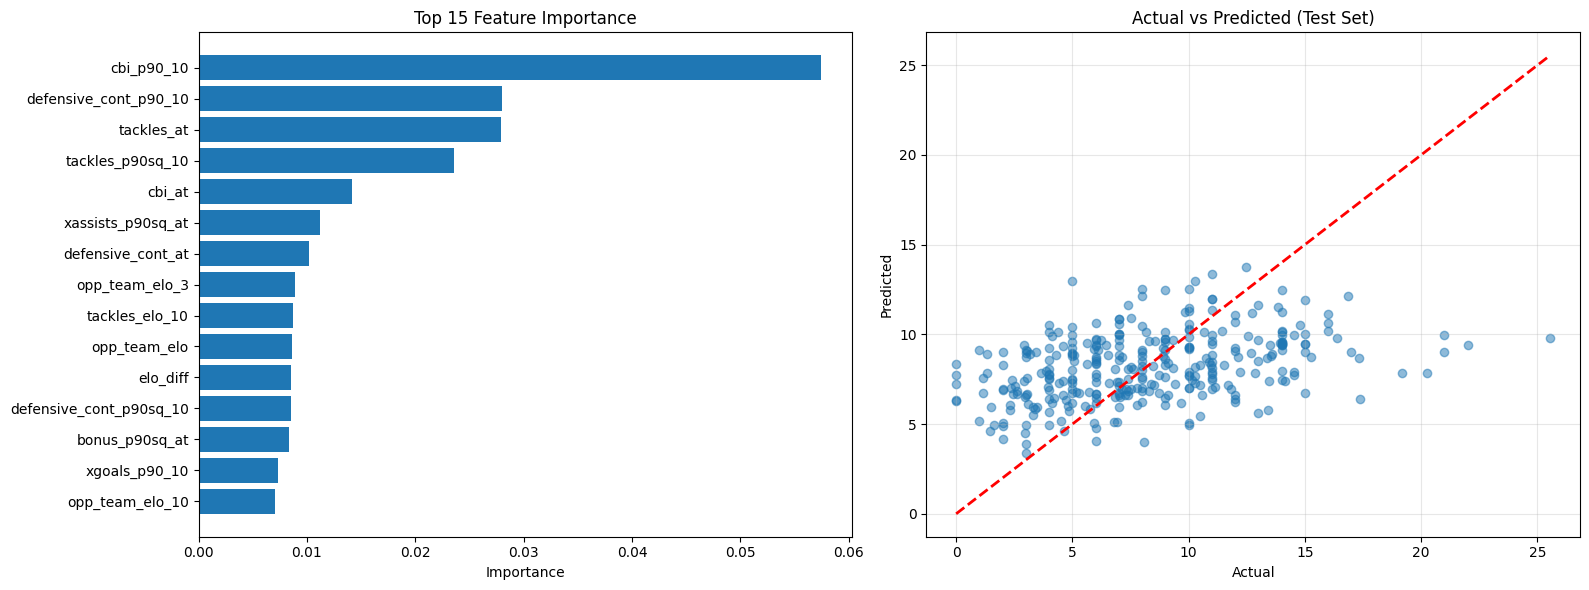

target=defensive_contribution_per90, DEF_defcon_predictor
Cleaned df size: 1375/16835

Training Set Performance:
R² Score: 0.7814
RMSE: 1.8173
MAE: 1.4634

Test Set Performance:
R² Score: 0.0337
RMSE: 3.8126
MAE: 2.8649

Top 20 Feature Importances:
               feature  importance
   xassists_elo_p90_10    0.019872
                 cbi_5    0.018848
           cbi_p90sq_3    0.017837
                cbi_at    0.017264
          opp_team_elo    0.014726
              elo_diff    0.013149
opp_team_elo_elo_p90_5    0.012986
           cbi_p90sq_5    0.011311
       opp_team_elo_10    0.010242
     xassists_p90sq_10    0.009972
                cbi_10    0.009370
      xassists_p90sq_5    0.009193
      team_elo_p90sq_5    0.008357
         minutes_elo_5    0.008236
        opp_team_elo_3    0.008042
            cbi_elo_10    0.007583
defensive_cont_p90sq_3    0.007478
  opp_team_elo_p90sq_3    0.007352
             cbi_p90_5    0.007311
          cbi_p90sq_10    0.007110


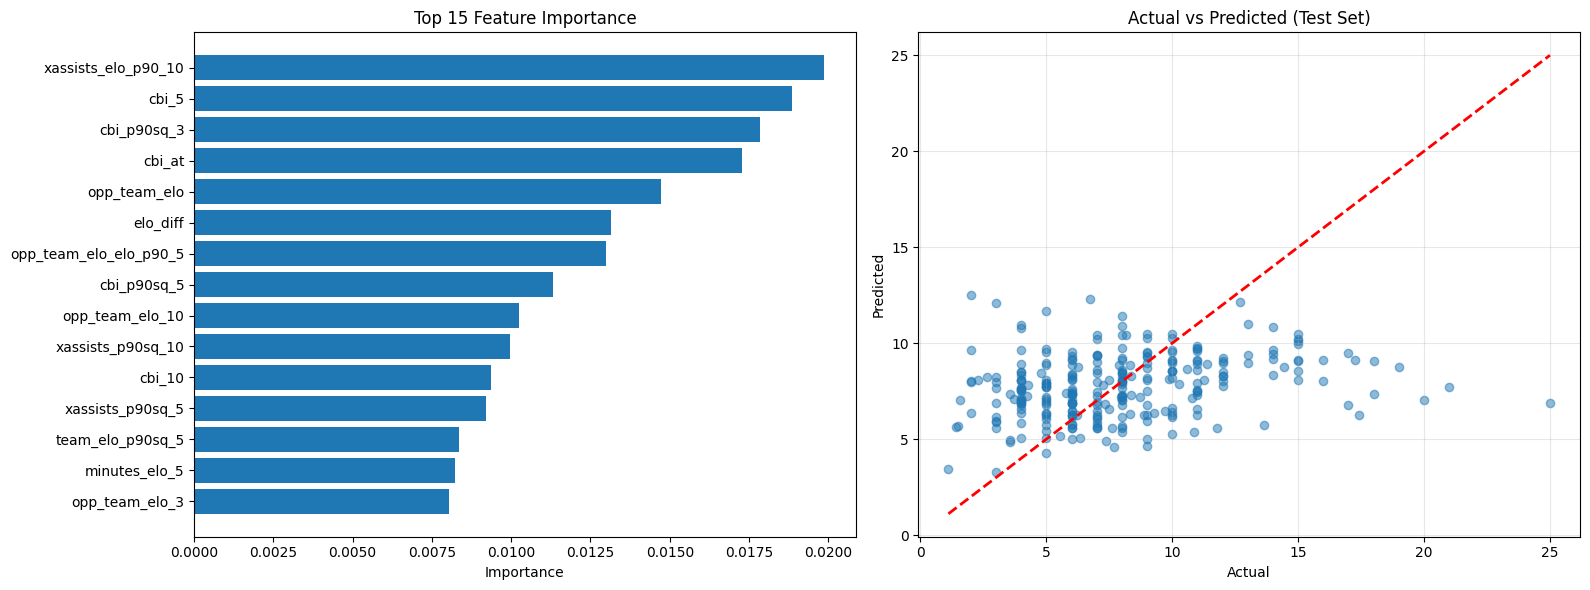

In [ ]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
    data=df[filtered],
    target='defensive_contribution_per90',
    positions={'FWD'})
    FWD_defcon_predictor.fit()
    FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
    data=df[filtered],
    target='defensive_contribution_per90',
    positions={'MID'})
    MID_defcon_predictor.fit()
    MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
    data=df[filtered],
    target='defensive_contribution_per90',
    positions={'DEF'})
    DEF_defcon_predictor.fit()
    DEF_defcon_predictor.plot_results()

Goals conceded per 90
Estimated λ (mean goals per match): 1.345


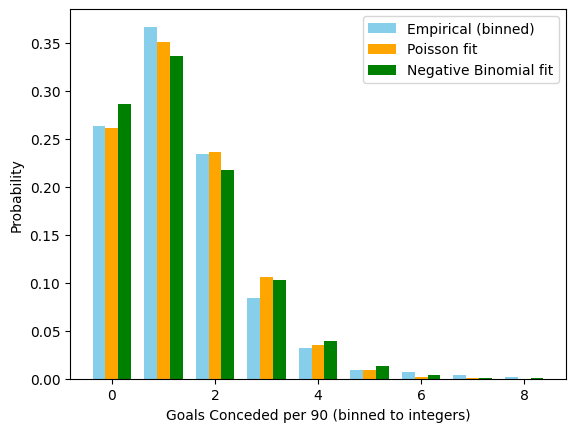

Mean: 1.336, Variance: 1.517
Overdispersion ratio (Var/Mean): 1.136
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.261


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
df['xgc_p90'] = (df['expected_goals_conceded'] / df['minutes']) * 90

# Filter to reasonable samples
data = df[(df['minutes'] > 0) & (df['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.300


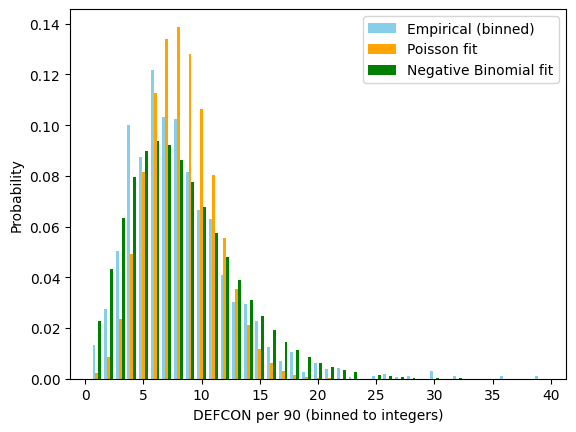

Mean: 8.294, Variance: 21.723
Overdispersion ratio (Var/Mean): 2.619
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [ ]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean defcon per 90): 3.210


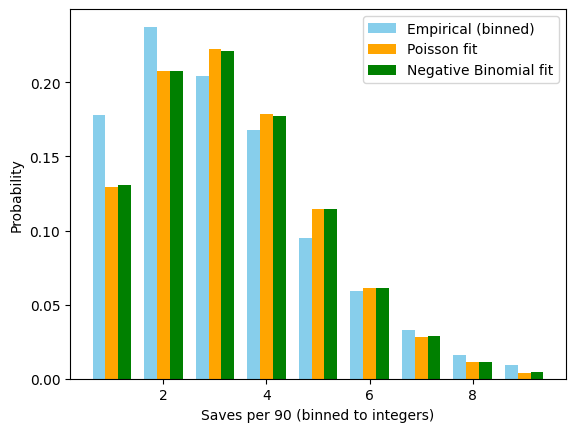

Mean: 3.210, Variance: 3.250
Overdispersion ratio (Var/Mean): 1.012
✅ Poisson assumption looks reasonable.


In [ ]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.448
Model:                            OLS   Adj. R-squared (uncentered):              0.448
Method:                 Least Squares   F-statistic:                          3.293e+04
Date:                Mon, 22 Dec 2025   Prob (F-statistic):                        0.00
Time:                        20:22:55   Log-Likelihood:                         -38263.
No. Observations:               40614   AIC:                                  7.653e+04
Df Residuals:                   40613   BIC:                                  7.654e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

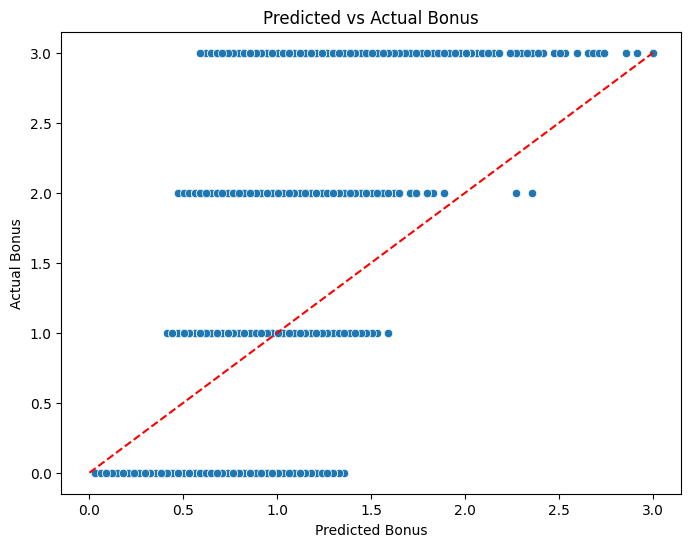

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.459351  0.231141  1.106018  1.948089
FWD           0.331945  0.199002  1.047444  1.708396
GK            0.491454  0.245797  1.115757  2.012529
GKP                NaN       NaN       NaN       NaN
MID           0.395181  0.245621  1.049860  1.823534


C:\Users\Chris\AppData\Local\Temp\ipykernel_16108\2893669323.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = df.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [ ]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
filtered = (df['minutes']>45) & (df['bonus']>=0) & (df['bps']>0) & (df['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=df[filtered]).fit()
print(model.summary())

df['bonus_pred'] = model.predict(df[filtered])
df['bonus_pred'] = np.clip(df['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=df)
plt.plot([df['bonus'].min(), df['bonus'].max()],
         [df['bonus'].min(), df['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = df.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [ ]:
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=stats_current_gameweek+1)]

In [ ]:
prediction_data.pivot_table(index='event',values='minutes',aggfunc='count')

,minutes
event,
17.0,470
18.0,0
19.0,0
20.0,0
21.0,0
22.0,0
23.0,0
24.0,0
25.0,0


In [ ]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [ ]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_16108\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    10340.000000
mean        41.014726
std         28.483927
min          0.060000
25%         14.365893
50%         39.134112
75%         67.767867
max         89.978950
Name: mins_pred, dtype: float64

In [ ]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_16108\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    9680.000000
mean        0.187073
std         0.147004
min         0.017704
25%         0.065185
50%         0.143676
75%         0.284160
max         1.043553
Name: xgp90_pred, dtype: float64

In [ ]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_16108\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    9680.000000
mean        0.112321
std         0.088036
min         0.012689
25%         0.046766
50%         0.089714
75%         0.153211
max         0.815377
Name: xap90_pred, dtype: float64

In [ ]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_16108\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    10340.000000
mean         1.339655
std          0.333063
min          0.257073
25%          1.123669
50%          1.335335
75%          1.561863
max          2.435100
Name: xgcp90_pred, dtype: float64

In [ ]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_16108\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    10340.000000
mean        17.648031
std          6.169975
min          0.345805
25%         14.626411
50%         17.199295
75%         20.416174
max         53.557779
Name: xbpsp90_pred, dtype: float64

In [ ]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_16108\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    660.000000
mean       2.693470
std        0.528702
min        1.202532
25%        2.318720
50%        2.708908
75%        2.998366
max        5.082704
Name: xsavesp90_pred, dtype: float64

In [ ]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_16108\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    9680.000000
mean        7.773673
std         2.033272
min         1.853687
25%         6.503756
50%         7.869843
75%         9.111694
max        17.373573
Name: xdefconp90_pred, dtype: float64

In [ ]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
129489,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,17.0,Burnley,882.423475,1.535673,0.317261,0.271944,1.031496
129610,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,18.0,Brentford,1056.999669,1.356149,0.283605,0.180769,1.356793
129615,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,19.0,Chelsea,1144.176148,1.368512,0.277525,0.164205,1.434341
129643,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,20.0,Arsenal,1254.607056,1.368512,0.277525,0.163547,1.480273
129646,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,21.0,Spurs,1006.497800,1.318511,0.297312,0.195870,1.214795


In [ ]:
prediction_data[
    (prediction_data['event']==picks_current_gameweek+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
142823,Nick Woltemade,714.0,73.0,Newcastle,FWD,20252026.0,17.0,Chelsea,1145.331923,72.716970,1.043553,0.020298,1.121905
134535,Erling Haaland,430.0,150.0,Man City,FWD,20252026.0,17.0,West Ham,983.888224,86.244546,0.905240,0.094644,1.129181
133398,David Brooks,86.0,50.0,Bournemouth,MID,20252026.0,17.0,Burnley,882.423475,15.773383,0.749539,0.191527,0.593875
139163,Jørgen Strand Larsen,654.0,62.0,Wolves,FWD,20252026.0,17.0,Brentford,1050.863392,73.185888,0.642159,0.013161,1.535780
146663,Viktor Gyökeres,666.0,88.0,Arsenal,FWD,20252026.0,17.0,Everton,1072.743665,58.244242,0.631508,0.058442,1.246174
140052,Liam Delap,250.0,62.0,Chelsea,FWD,20252026.0,17.0,Newcastle,1104.995921,21.526703,0.590672,0.024254,1.157645
131820,Brian Brobbey,730.0,55.0,Sunderland,FWD,20252026.0,17.0,Brighton,1096.124370,62.960101,0.561340,0.039857,1.435292
147133,Yoane Wissa,135.0,73.0,Newcastle,FWD,20252026.0,17.0,Chelsea,1145.331923,15.964146,0.551732,0.092804,1.339100
140688,Marc Guiu Paz,252.0,42.0,Chelsea,FWD,20252026.0,17.0,Newcastle,1104.995921,6.485373,0.550644,0.033055,1.218386
130937,Armando Broja,680.0,52.0,Burnley,FWD,20252026.0,17.0,Bournemouth,1054.912816,33.143493,0.549066,0.036143,1.805686


In [ ]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [ ]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [ ]:
scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] >= 60:
            return 2
        elif x['mins_pred'] > 0:
            return 1
        else:
            return 0
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_16108\282654768.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_16108\282654768.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_

In [ ]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                       'xpoints']]
predictions

,player_name_id,team_name,team_elo,element,position,opp_team_name,opp_team_elo,season,value,event,...,xgcp90_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
127565,Bashir Humphreys,Burnley,882.423475,193.0,DEF,Bournemouth,1054.912816,20252026.0,39.0,17.0,...,1.858361,1,0.030105,0.012897,0.623712,0.0,-0.685237,0.553871,0.276307,1.811655
127642,Bashir Humphreys,Burnley,887.016794,193.0,DEF,Everton,1067.428668,20252026.0,39.0,18.0,...,1.863153,1,0.027604,0.011823,0.620731,0.0,-0.687574,0.553871,0.296357,1.822812
127781,Bashir Humphreys,Burnley,887.016794,193.0,DEF,Newcastle,1106.151696,20252026.0,39.0,19.0,...,1.815852,1,0.027292,0.012734,0.650797,0.0,-0.664526,0.553871,0.205478,1.785646
127884,Bashir Humphreys,Burnley,887.016794,193.0,DEF,Brighton,1095.940270,20252026.0,39.0,20.0,...,1.846252,1,0.027292,0.012734,0.631310,0.0,-0.679333,0.553871,0.206334,1.752208
127899,Bashir Humphreys,Burnley,887.016794,193.0,DEF,Man Utd,1061.666474,20252026.0,39.0,21.0,...,1.856703,1,0.027604,0.011823,0.624747,0.0,-0.684429,0.553871,0.303122,1.836739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147517,Álex Jiménez Sánchez,Bournemouth,1050.319497,713.0,DEF,Leeds,963.490409,20252026.0,45.0,34.0,...,1.049813,2,0.142888,0.139465,1.400013,0.0,-0.305532,0.553871,0.478314,4.409019
147518,Álex Jiménez Sánchez,Bournemouth,1050.319497,713.0,DEF,Crystal Palace,1093.344095,20252026.0,45.0,35.0,...,1.357215,2,0.130149,0.138678,1.029507,0.0,-0.445167,0.553871,0.393718,3.800756
147519,Álex Jiménez Sánchez,Bournemouth,1050.319497,713.0,DEF,Fulham,1036.411749,20252026.0,45.0,36.0,...,1.101221,2,0.131793,0.138921,1.329860,0.0,-0.328244,0.553871,0.435980,4.262180
147520,Álex Jiménez Sánchez,Bournemouth,1050.319497,713.0,DEF,Man City,1248.652906,20252026.0,45.0,37.0,...,1.808882,2,0.120466,0.151299,0.655349,0.0,-0.661135,0.553871,0.134528,2.954378


In [ ]:
prediction_data[
    (prediction_data['event']==picks_current_gameweek+1)
    &(prediction_data['mins_pred']>60)
    #&(prediction_data['position'].isin(['MID','FWD']))
    ][["player_name_id","element","value","team_name","position","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xdefconp90_pred','xbpsp90_pred','xpoints'
    ]].sort_values(by='xpoints',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xdefconp90_pred,xbpsp90_pred,xpoints
138953,Jurriën Timber,8.0,65.0,Arsenal,DEF,17.0,Everton,1072.743665,81.224164,0.311216,0.048947,5.968677,19.689621,7.831050
134535,Erling Haaland,430.0,150.0,Man City,FWD,17.0,West Ham,983.888224,86.244546,0.905240,0.094644,5.565414,53.557779,7.583340
142823,Nick Woltemade,714.0,73.0,Newcastle,FWD,17.0,Chelsea,1145.331923,72.716970,1.043553,0.020298,2.819466,43.035083,6.953846
144428,Riccardo Calafiori,7.0,57.0,Arsenal,DEF,17.0,Everton,1072.743665,77.891090,0.050004,0.034051,6.407565,24.153726,6.675862
146953,William Saliba,6.0,59.0,Arsenal,DEF,17.0,Everton,1072.743665,69.329614,0.022508,0.017931,6.752574,23.311502,6.449906
139218,Keane Lewis-Potter,107.0,48.0,Brentford,DEF,17.0,Wolves,909.273408,64.994116,0.327812,0.215845,4.773842,38.373397,6.414250
143988,Piero Hincapié,725.0,55.0,Arsenal,DEF,17.0,Everton,1072.743665,84.947099,0.027216,0.035538,10.868413,24.347396,6.272126
141356,Matheus Santos Carneiro da Cunha,450.0,79.0,Man Utd,MID,17.0,Aston Villa,1181.038472,77.090960,0.533516,0.111056,8.234734,24.500232,6.057949
132075,Bukayo Saka,16.0,103.0,Arsenal,MID,17.0,Everton,1072.743665,72.577619,0.364895,0.295538,5.945365,26.883590,5.970300
142546,Morgan Rogers,47.0,71.0,Aston Villa,MID,17.0,Man Utd,1068.537039,83.851996,0.378956,0.108413,7.157392,33.393769,5.854521


In [ ]:
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10340 entries, 0 to 10339
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          10340 non-null  object 
 1   team_name               10340 non-null  object 
 2   team_elo                10340 non-null  float64
 3   element                 10340 non-null  float64
 4   position                10340 non-null  object 
 5   opp_team_name           10340 non-null  object 
 6   opp_team_elo            10340 non-null  float64
 7   season                  10340 non-null  float64
 8   value                   10340 non-null  float64
 9   event                   10340 non-null  float64
 10  mins_pred               10340 non-null  float64
 11  xgp90_pred              9680 non-null   float64
 12  xap90_pred              9680 non-null   float64
 13  xgcp90_pred             10340 non-null  float64
 14  xpoints_mins            10340 non-null

In [ ]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0
""")

In [ ]:
current_gameweek = picks_current_gameweek
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gameweek}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gameweek}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gameweek}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gameweek}
        AND member = '{my_name}'
    )
""")

In [ ]:
print(f"Gameweek {picks_current_gameweek+1} Predictions")
prediction_data[
    prediction_data['event']==picks_current_gameweek+1
][["player_name_id","element",'event',"value","team_name","position","opp_team_name","opp_team_elo"
   ,'mins_pred', 'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets', 
   'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
   'xpoints'
   ]].sort_values(by='xpoints',ascending=False
    ).head(10)

Gameweek 17 Predictions


,player_name_id,element,event,value,team_name,position,opp_team_name,opp_team_elo,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
138953,Jurriën Timber,8.0,17.0,65.0,Arsenal,DEF,Everton,1072.743665,81.224164,2,1.685217,0.132523,2.921060,0.0,-0.040496,0.553871,0.578875,7.831050
134535,Erling Haaland,430.0,17.0,150.0,Man City,FWD,West Ham,983.888224,86.244546,2,3.469866,0.272083,0.000000,0.0,0.000000,0.266792,1.574599,7.583340
142823,Nick Woltemade,714.0,17.0,73.0,Newcastle,FWD,Chelsea,1145.331923,72.716970,2,3.372622,0.049199,0.000000,0.0,0.000000,0.266792,1.265231,6.953846
144428,Riccardo Calafiori,7.0,17.0,57.0,Arsenal,DEF,Everton,1072.743665,77.891090,2,0.259659,0.088408,3.091929,0.0,-0.028125,0.553871,0.710120,6.675862
146953,William Saliba,6.0,17.0,59.0,Arsenal,DEF,Everton,1072.743665,69.329614,2,0.104031,0.041438,3.093246,0.0,-0.028039,0.553871,0.685358,6.449906
139218,Keane Lewis-Potter,107.0,17.0,48.0,Brentford,DEF,Wolves,909.273408,64.994116,2,1.420389,0.467622,1.213567,0.0,-0.369377,0.553871,1.128178,6.414250
143988,Piero Hincapié,725.0,17.0,55.0,Arsenal,DEF,Everton,1072.743665,84.947099,2,0.154129,0.100628,2.798645,0.0,-0.050961,0.553871,0.715813,6.272126
141356,Matheus Santos Carneiro da Cunha,450.0,17.0,79.0,Man Utd,MID,Aston Villa,1181.038472,77.090960,2,2.284958,0.285382,0.263560,0.0,0.000000,0.503743,0.720307,6.057949
132075,Bukayo Saka,16.0,17.0,103.0,Arsenal,MID,Everton,1072.743665,72.577619,2,1.471290,0.714982,0.489908,0.0,0.000000,0.503743,0.790378,5.970300
142546,Morgan Rogers,47.0,17.0,71.0,Aston Villa,MID,Man Utd,1068.537039,83.851996,2,1.765346,0.303021,0.300635,0.0,0.000000,0.503743,0.981777,5.854521


In [ ]:
current_gameweek=picks_current_gameweek
print(f"Next 5 GWs: GW{current_gameweek+1} - GW{current_gameweek+5}")
next_5_gws_filter = (prediction_data['event']>=current_gameweek)&(prediction_data['event']<=current_gameweek+5)
prediction_data[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW17 - GW21


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
122,Erling Haaland,397.488254,10,16.780008,1.206317,0.000000,0.0,0.000000,1.333962,6.372371,35.692658
242,Jurriën Timber,402.446718,10,5.044148,0.614554,10.322351,0.0,-0.813436,2.769356,2.409495,30.346469
384,Riccardo Calafiori,371.879476,10,1.222796,0.382990,12.680670,0.0,-0.439760,2.769356,3.205315,29.821367
305,Matheus Santos Carneiro da Cunha,350.211258,10,8.420451,2.071143,1.361250,0.0,0.000000,2.518713,3.819928,28.191484
375,Piero Hincapié,423.182532,10,1.140226,0.543139,11.428271,0.0,-0.597615,2.769356,2.907016,28.190393
333,Morgan Rogers,420.009821,10,7.644573,2.254813,1.226928,0.0,0.000000,2.518713,4.160652,27.805679
58,Bukayo Saka,345.668287,10,5.816867,2.595795,2.211122,0.0,0.000000,2.518713,3.883552,27.026050
239,Joško Gvardiol,360.221652,10,4.853901,0.813583,6.725534,0.0,-1.632085,2.769356,3.244048,26.774337
102,Dominic Calvert-Lewin,372.084103,10,11.925164,0.506432,0.000000,0.0,0.000000,1.333962,2.351015,26.116573
86,Daniel Ballard,425.079919,10,2.100812,1.534007,7.639122,0.0,-1.382131,2.769356,2.977999,25.639166


In [ ]:
print("Rest of Season Predictions")
prediction_data.groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
122,Erling Haaland,1714.141526,44,73.212934,5.684365,0.000000,0.0,0.000000,5.869434,26.771711,155.538444
384,Riccardo Calafiori,1589.992687,44,6.138739,1.802747,59.520670,0.0,-1.492545,12.185166,14.437758,136.592535
242,Jurriën Timber,1765.349589,44,20.619146,2.890895,45.578253,0.0,-3.369135,12.185166,10.729969,132.634294
375,Piero Hincapié,1860.940765,44,6.702946,2.653294,53.097061,0.0,-2.198482,12.185166,12.709801,129.149786
333,Morgan Rogers,1843.552464,44,32.607594,11.468761,6.422518,0.0,0.000000,11.082337,17.797213,123.378423
58,Bukayo Saka,1503.524419,44,24.977706,10.985308,10.710257,0.0,0.000000,11.082337,17.671257,119.426865
102,Dominic Calvert-Lewin,1601.274125,44,56.290310,2.333362,0.000000,0.0,0.000000,5.869434,10.504978,118.998085
239,Joško Gvardiol,1542.499152,44,20.166626,3.985265,31.301145,0.0,-6.668457,12.185166,13.978087,118.947831
305,Matheus Santos Carneiro da Cunha,1518.740287,44,32.973329,8.112321,5.449253,0.0,0.000000,11.082337,15.780174,117.397414
86,Daniel Ballard,1886.535265,44,9.888417,7.836210,34.566181,0.0,-5.759588,12.185166,12.638373,115.354760


In [ ]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': picks_current_gameweek
})

In [ ]:
# # Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [ ]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value,
            pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, pg.bonus, 
            pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, pg.expected_assists, 
            pg.expected_goal_involvements, pg.expected_goals, pg.expected_goals_conceded, 
            pg.starts, pg.cbi, pg.defensive_contribution, pg.recoveries, pg.tackles, pg.saves 
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    WHERE 1=0;  -- Empty table with correct schema
""")

In [ ]:
# Step 1: Insert new predictions that don't exist yet
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, 
    opp_team_elo, value, event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,  -- Add these explicitly
    fixture, total_points, minutes, goals_scored, assists, bonus, 
    bps, clean_sheets, goals_conceded, was_home, expected_assists, 
    expected_goal_involvements, expected_goals, expected_goals_conceded, 
    starts, cbi, defensive_contribution, recoveries, tackles, saves
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, 
    p.opp_team_name, p.opp_team_elo, p.value, p.event, p.season, 
    p.xpoints, p.prediction_timestamp, p.prediction_gameweek,  -- Include new columns
    pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, 
    pg.bonus, pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, 
    pg.expected_assists, pg.expected_goal_involvements, pg.expected_goals, 
    pg.expected_goals_conceded, pg.starts, pg.cbi, pg.defensive_contribution, 
    pg.recoveries, pg.tackles, pg.saves
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season
WHERE NOT EXISTS (
    SELECT 1 
    FROM predictions_allgws pa 
    WHERE pa.player_name_id = p.player_name_id 
        AND pa.event = p.event 
        AND pa.season = p.season
);
""")

In [ ]:
# # Step 1: Insert new predictions that don't exist yet
# db_creator.execute_sql("""
# INSERT INTO predictions_allgws
# SELECT p.*, 
#             -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value,
#             pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, pg.bonus, 
#             pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, pg.expected_assists, 
#             pg.expected_goal_involvements, pg.expected_goals, pg.expected_goals_conceded, 
#             pg.starts, pg.cbi, pg.defensive_contribution, pg.recoveries, pg.tackles, pg.saves
# FROM predictions p
# LEFT JOIN playergw pg 
#     ON p.player_name_id = pg.player_name_id 
#     AND p.event = pg.event 
#     AND p.season = pg.season
# WHERE NOT EXISTS (
#     SELECT 1 
#     FROM predictions_allgws pa 
#     WHERE pa.player_name_id = p.player_name_id 
#         AND pa.event = p.event 
#         AND pa.season = p.season
# );
# """)

# # Step 2: Update existing predictions with actual results (where total_points is still NULL)
# db_creator.execute_sql("""
# UPDATE predictions_allgws
# SET 
#     fixture = pg.fixture,
#     total_points = pg.total_points,
#     minutes = pg.minutes,
#     goals_scored = pg.goals_scored,
#     assists = pg.assists,
#     bonus = pg.bonus,
#     bps = pg.bps,
#     clean_sheets = pg.clean_sheets,
#     goals_conceded = pg.goals_conceded,
#     expected_assists = pg.expected_assists,
#     expected_goal_involvements = pg.expected_goal_involvements,
#     expected_goals = pg.expected_goals,
#     expected_goals_conceded = pg.expected_goals_conceded,
#     starts = pg.starts,
#     cbi = pg.cbi,
#     defensive_contribution = pg.defensive_contribution,
#     recoveries = pg.recoveries,
#     tackles = pg.tackles,
#     saves = pg.saves
# FROM playergw pg
# WHERE predictions_allgws.player_name_id = pg.player_name_id
#     AND predictions_allgws.event = pg.event
#     AND predictions_allgws.season = pg.season
#     AND predictions_allgws.total_points IS NULL;  -- Only update rows without actual points yet
# """)

# print(f"Successfully added/updated gameweek {picks_current_gameweek} predictions in predictions_allgws")

In [ ]:
# # # Create predictions_allgws if it doesn't exist, otherwise append
# # # creates new rows every time the script is loaded
# # db_creator.execute_sql("""
# #     CREATE TABLE IF NOT EXISTS predictions_allgws AS
# #     SELECT * FROM predictions WHERE 1=0;  -- Creates empty table with same schema, 1=0 ensures no data copied, just structure
    
# #     INSERT INTO predictions_allgws
# #     SELECT * FROM predictions;
# # """)

# # Create predictions_allgws if it doesn't exist
# db_creator.execute_sql("""
#     CREATE TABLE IF NOT EXISTS predictions_allgws AS
#     SELECT p.*,
#             -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value,
#             pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, pg.bonus, 
#             pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, pg.expected_assists, 
#             pg.expected_goal_involvements, pg.expected_goals, pg.expected_goals_conceded, 
#             pg.starts, pg.cbi, pg.defensive_contribution, pg.recoveries, pg.tackles, pg.saves 
            
#     FROM predictions p
#     LEFT JOIN playergw pg 
#         ON p.player_name_id = pg.player_name_id 
#         AND p.event = pg.event
#         AND p.season = pg.season
#     WHERE 1=0;  -- Empty table with correct schema
# """)

# # Insert new predictions from current gameweek
# db_creator.execute_sql("""
#     INSERT INTO predictions_allgws
#     SELECT p.*, 
#             -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value,
#             pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, pg.bonus, 
#             pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, pg.expected_assists, 
#             pg.expected_goal_involvements, pg.expected_goals, pg.expected_goals_conceded, 
#             pg.starts, pg.cbi, pg.defensive_contribution, pg.recoveries, pg.tackles, pg.saves
                       
#     FROM predictions p
#     LEFT JOIN playergw pg 
#         ON p.player_name_id = pg.player_name_id 
#         AND p.event = pg.event
#         AND p.season = pg.season;
# """)

# print(f"Successfully added gameweek {picks_current_gameweek} predictions to predictions_allgws")

In [ ]:
df = db_creator.table_to_df('predictions_allgws')
future_filter = (#df['season']==20252026)&(
                #df['event']>=13)&(
                df['prediction_gameweek']==16)
df[['player_name_id','event','season','total_points','minutes']][future_filter].head()

,player_name_id,event,season,total_points,minutes
0,Gabriel dos Santos Magalhães,17.0,20252026.0,NaN,NaN
1,Gabriel dos Santos Magalhães,18.0,20252026.0,NaN,NaN
2,Gabriel dos Santos Magalhães,19.0,20252026.0,NaN,NaN
3,Gabriel dos Santos Magalhães,20.0,20252026.0,NaN,NaN
4,Gabriel dos Santos Magalhães,21.0,20252026.0,NaN,NaN


In [ ]:
df = db_creator.table_to_df('playergw')
future_filter = (df['season']==20252026)&(df['event']>=13)&(df['player_name_id']=='Erling Haaland')
df[['player_name_id','event','season','total_points','minutes']][future_filter].head()

,player_name_id,event,season,total_points,minutes
178636,Erling Haaland,13.0,20252026.0,2.0,90.0
178637,Erling Haaland,14.0,20252026.0,14.0,90.0
178638,Erling Haaland,15.0,20252026.0,2.0,68.0
178639,Erling Haaland,16.0,20252026.0,13.0,90.0
178640,Erling Haaland,17.0,20252026.0,16.0,90.0


In [ ]:
df = db_creator.table_to_df('predictions')
future_filter = (df['season']==20252026)&(df['event']<=20)&(df['player_name_id']=='Erling Haaland')
df[['player_name_id','event','season','xpoints']][future_filter]

,player_name_id,event,season,xpoints
8899,Erling Haaland,17.0,20252026.0,7.583340
8900,Erling Haaland,18.0,20252026.0,7.060050
8901,Erling Haaland,19.0,20252026.0,7.042710
8902,Erling Haaland,20.0,20252026.0,6.968552


In [ ]:
df = db_creator.table_to_df('predictions_allgws')
df[['player_name_id','prediction_timestamp','event','xpoints','total_points','minutes']][
    (df['season']==20252026)&(
    df['event']<=17)&(df['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points,minutes
5808,Erling Haaland,2025-12-18 14:48:05.460857,17.0,5.932372,NaN,NaN


In [ ]:
# Get the data from the predictions table
df = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df['prediction_gameweek']>=13)&(
            df['event']>=13)&(
                df['event']<=20)&(
            df['season']==20252026)&(
            df['player_name_id']=='Erling Haaland')
df_complete = df[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

xpoints
prediction_timestamp       prediction_gameweek season     event          
2025-12-18 14:48:05.460857 16                  20252026.0 17.0   5.932372
                                                          18.0   5.875096
                                                          19.0   5.898596
                                                          20.0   5.844356

In [ ]:
# Get the data from the predictions table
df = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df['event'] >= 13) & (df['minutes'] >= 1)
df_complete = df.dropna(subset=['total_points'])[gw_filter]

df_complete.pivot_table(index=['season','event'], values=['xpoints','total_points'], aggfunc='mean')

C:\Users\Chris\AppData\Local\Temp\ipykernel_16108\686688159.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_complete = df.dropna(subset=['total_points'])[gw_filter]


,,total_points,xpoints
season,event,,
20252026.0,17.0,1.0,2.381662


c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Correlation: nan
Mean Absolute Error: 1.382
Root Mean Squared Error: 1.389


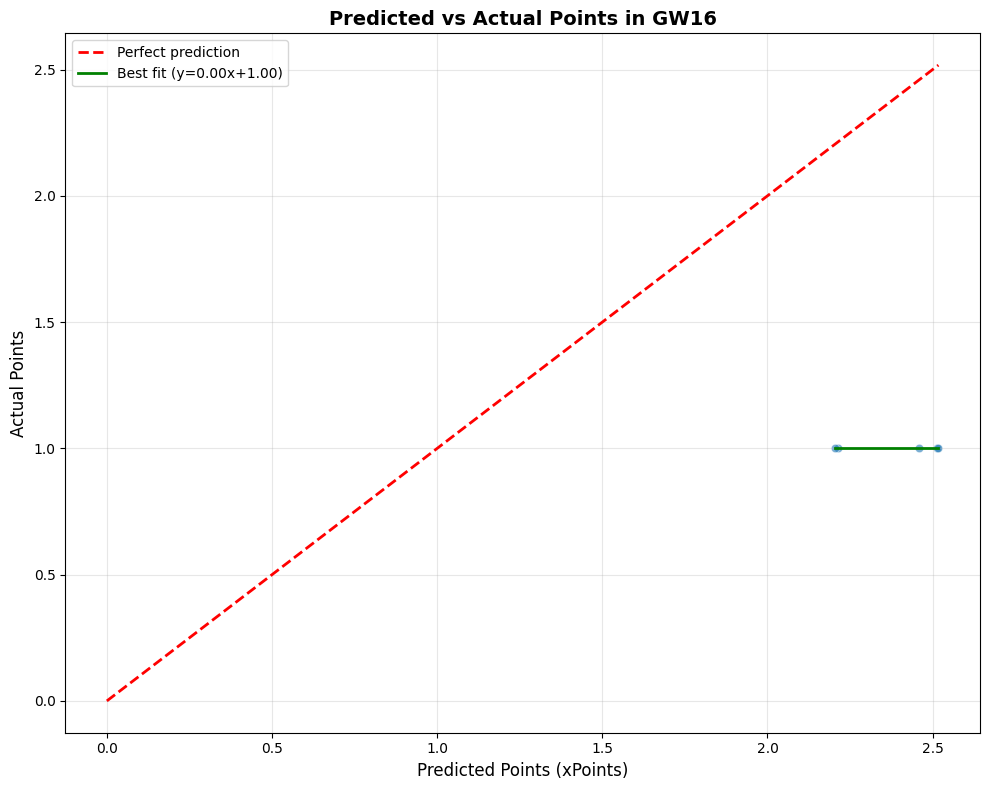

In [ ]:
# Create the plot
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# Add a diagonal reference line (perfect predictions)
max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# Add regression line showing actual correlation
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

plt.xlabel('Predicted Points (xPoints)', fontsize=12)
plt.ylabel('Actual Points', fontsize=12)
plt.title(f'Predicted vs Actual Points in GW{stats_current_gameweek}', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 8.91 minute(s)

Finished in 5.58 minute(s)
